# Geographical Patterns of Dementia Prevalence Across Texas Counties
## Association with Lithium and Other Minerals Found in Groundwater

**Authors:** Chloe D. Barker, Tracy Dower, Jacob Turner  
**Institution:** Dedman College of Humanities and Sciences, Southern Methodist University  
**Course:** DS Capstone

---

## Table of Contents
1. [Setup & Data Loading](#section-0)
2. [2020 Census Population by Texas County](#section-1)
3. [TWDB Groundwater Quality Data](#section-2)
4. [Groundwater Parameter Feature Engineering](#section-3)
5. [NORC Dementia DataHub — 2020 County Prevalence](#section-4)
6. [Exploratory Data Analysis (EDA)](#section-5)
7. [Exposure Homogeneity Classification](#section-6)
8. [GIS: Texas County Boundaries](#section-7)
9. [Choropleth Maps — Primary Study Variables](#section-8)
10. [Choropleth Maps — Co-occurring Minerals](#section-9)
11. [Choropleth Maps — Homogeneous Lithium Counties](#section-10)
12. [Regression — Full County Sample](#section-11)
13. [Regression — Homogeneous County Subsample](#section-12)
14. [Nonparametric Inference — Permutation Test & Bootstrap CI](#section-13)
15. [Influence Diagnostics & Scatterplots](#section-14)
16. [Model Comparison Summary](#section-15)
17. [Interpretation & Key Takeaways](#section-16)

---
## Section 0: Setup & Data Loading <a id='section-0'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings('ignore')

# Load county FIPS lookup
county_FIPS = pd.read_csv("Texas_County_Name_FIPS_Code.csv")
county_FIPS["FIPS_Code"] = county_FIPS["FIPS_Code"].astype(int)

print(f"County FIPS table loaded: {county_FIPS.shape[0]} counties")
county_FIPS.head()

SMU_BLUE = "#354CA1"
SMU_RED = "#CC0035"
SMU_GREEN_BLUE = "#59C3C3"

County FIPS table loaded: 254 counties


---
## Section 1: 2020 Census Population by Texas County <a id='section-1'></a>

We pull age-stratified population counts from the ACS 5-year estimates via the Census API. These are used to describe county demographics and contextualize dementia prevalence.


In [2]:
import requests

base_url = "https://api.census.gov/data/2020/acs/acs5"
vars = [
    "B01001_001E",                                              # total population
    "B01001_020E", "B01001_044E",                               # 65-69  (M, F)
    "B01001_021E", "B01001_045E",                               # 70-74
    "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E", # 75+   (M)
    "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E", # 75+   (F)
]
params = {
    "get": ",".join(vars),
    "for": "county:*",
    "in": "state:48",
    "key": "00cfeb831fad13f7202098854f06096c0a8a0d11"
}

resp = requests.get(base_url, params=params)
data = resp.json()

tx_county_pop_2020 = pd.DataFrame(data[1:], columns=data[0])
tx_county_pop_2020["county"] = tx_county_pop_2020["county"].astype(int)
tx_county_pop_2020 = tx_county_pop_2020.merge(
    county_FIPS[["County_Name", "FIPS_Code"]],
    left_on="county", right_on="FIPS_Code", how="left"
)

# Convert to numeric
tx_county_pop_2020[vars] = tx_county_pop_2020[vars].apply(pd.to_numeric)

# Build age buckets matching the NORC dementia age categories
tx_county_pop_2020["age_65_69"]   = tx_county_pop_2020["B01001_020E"] + tx_county_pop_2020["B01001_044E"]
tx_county_pop_2020["age_70_74"]   = tx_county_pop_2020["B01001_021E"] + tx_county_pop_2020["B01001_045E"]
tx_county_pop_2020["age_75_79"]   = tx_county_pop_2020["B01001_022E"] + tx_county_pop_2020["B01001_046E"]
tx_county_pop_2020["age_80_84"]   = tx_county_pop_2020["B01001_023E"] + tx_county_pop_2020["B01001_047E"]
tx_county_pop_2020["age_85_plus"] = (
    tx_county_pop_2020["B01001_024E"] + tx_county_pop_2020["B01001_025E"] +
    tx_county_pop_2020["B01001_048E"] + tx_county_pop_2020["B01001_049E"]
)
tx_county_pop_2020["age_65_plus"] = (
    tx_county_pop_2020["age_65_69"] + tx_county_pop_2020["age_70_74"] +
    tx_county_pop_2020["age_75_79"] + tx_county_pop_2020["age_80_84"] +
    tx_county_pop_2020["age_85_plus"]
)
tx_county_pop_2020["pct_65_plus"] = tx_county_pop_2020["age_65_plus"] / tx_county_pop_2020["B01001_001E"]

print(f"Census data loaded: {tx_county_pop_2020.shape[0]} counties")
# Sanity check: Collin County should be ~1,006,038
collin = tx_county_pop_2020[tx_county_pop_2020["County_Name"] == "Collin"]["B01001_001E"].values
print(f"Collin County total population: {collin[0]:,.0f}  (expected ~1,006,038)")


Census data loaded: 254 counties
Collin County total population: 1,006,038  (expected ~1,006,038)


---
## Section 2: TWDB Groundwater Quality Data <a id='section-2'></a>

We load and clean the Texas Water Development Board (TWDB) groundwater database. Key cleaning steps:
- Remove non-numeric state well number rows (these are reference/footnote rows embedded in the CSV)
- Filter to samples collected **on or before 2019-12-31** so water exposure predates the 2020 dementia outcome
- Merge county FIPS codes for later joins


In [3]:
water = pd.read_csv("All_Counties_Water_Quality_with_COUNTY_NAME.csv")
water_clean = water.copy()
water_clean["StateWellNumber"] = water_clean["StateWellNumber"].astype(str)

# Remove reference/footnote rows
rows_to_drop = []
for county, grp in water_clean.groupby("SourceFile", sort=False):
    idx = grp.index
    non_numeric = ~grp["StateWellNumber"].str.fullmatch(r"\d+")
    if non_numeric.any():
        first_ref_idx = grp.loc[non_numeric].index[0]
        rows_to_drop.extend(range(first_ref_idx, idx[-1] + 1))

water_clean = water_clean.drop(index=rows_to_drop).reset_index(drop=True)

# Parse county name and merge FIPS
water_clean["County_Name"] = water_clean["SourceFile"].str.replace(" County", "", regex=False)
water_clean = water_clean.merge(county_FIPS, on="County_Name", how="left")

# Parse dates and restrict to pre-2020
water_clean["Date"] = pd.to_datetime(water_clean["Date"], errors="coerce")
water_clean = water_clean[water_clean["Date"] <= "2019-12-31"].copy()
water_clean["Year"] = water_clean["Date"].dt.year

print(f"Water data after cleaning: {water_clean.shape[0]:,} rows")
print(f"Date range: {water_clean['Date'].min().date()} to {water_clean['Date'].max().date()}")
print(f"Counties represented: {water_clean['County_Name'].nunique()}")


Water data after cleaning: 460,137 rows
Date range: 1919-06-28 to 2019-12-17
Counties represented: 243


---
## Section 3: Groundwater Parameter Feature Engineering (2010–2019) <a id='section-3'></a>

For each county × parameter, we compute six summary features over the 2010–2019 exposure window:
- **mean** and **median** concentration
- **standard deviation** (within-county variability)
- **n_samples** (data density)
- **pct_above_p90** (proportion of samples above statewide 90th percentile)
- **trend_slope** (linear trend in annual means, requires ≥3 distinct years)

The 13 parameters were chosen based on neurological relevance (lithium, lead, arsenic, manganese), geochemical co-occurrence with lithium (sodium, calcium, magnesium, hardness), and potential modifying roles (fluoride, selenium, aluminum, zinc, potassium).


In [4]:
# Parameters of interest — includes lithium and 12 co-occurring minerals
keep_params = [
    "ALUMINUM, DISSOLVED (UG/L AS AL)",
    "ARSENIC, DISSOLVED (UG/L AS AS)",
    "CALCIUM, DISSOLVED (MG/L AS CA)",
    "FLUORIDE, DISSOLVED (MG/L AS F)",
    "HARDNESS, TOTAL, CALCULATED (MG/L AS CACO3)",
    "LEAD, DISSOLVED (UG/L AS PB)",
    "LITHIUM, DISSOLVED (UG/L AS LI)",
    "MAGNESIUM, DISSOLVED (MG/L AS MG)",
    "MANGANESE, DISSOLVED (UG/L AS MN)",
    "POTASSIUM, DISSOLVED (MG/L AS K)",
    "SELENIUM, DISSOLVED (UG/L AS SE)",
    "SODIUM, DISSOLVED (MG/L AS NA)",
    "ZINC, DISSOLVED (UG/L AS ZN)"
]

def safe_slope(year, value):
    """Linear trend slope; returns NaN if insufficient data."""
    if year.nunique() < 3 or value.nunique() < 2:
        return np.nan
    try:
        return np.polyfit(year, value, 1)[0]
    except np.linalg.LinAlgError:
        return np.nan

# Restrict to 2010-2019 window and selected parameters
water_window = (
    water_clean
        .loc[
            water_clean["Date"].dt.year.between(2010, 2019) &
            water_clean["ParameterDescription"].isin(keep_params)
        ]
        .assign(
            Year=lambda d: d["Date"].dt.year,
            Parameter=lambda d: d["ParameterDescription"].str.split(",", n=1).str[0]
        )
)

# Statewide 90th percentile per parameter
p90_map = (
    water_window.groupby("Parameter")["ParameterValue"]
    .quantile(0.90).to_dict()
)
water_window = water_window.copy()
water_window["param_p90"] = water_window["Parameter"].map(p90_map)

# Compute features per Parameter × County
parameter_county_features = (
    water_window
        .groupby(["Parameter", "FIPS_Code", "County_Name"], group_keys=False)
        .apply(
            lambda d: pd.Series({
                "mean_value":    d["ParameterValue"].mean(),
                "median_value":  d["ParameterValue"].median(),
                "std_value":     d["ParameterValue"].std(),
                "n_samples":     d["ParameterValue"].count(),
                "pct_above_p90": (d["ParameterValue"] > d["param_p90"].iloc[0]).mean(),
                "trend_slope":   safe_slope(d["Year"], d["ParameterValue"])
            }),
            include_groups=False
        )
        .reset_index()
)

print(f"parameter_county_features shape: {parameter_county_features.shape}")
print(f"Parameters: {sorted(parameter_county_features['Parameter'].unique())}")
parameter_county_features.head(8)


parameter_county_features shape: (3146, 9)
Parameters: ['ALUMINUM', 'ARSENIC', 'CALCIUM', 'FLUORIDE', 'HARDNESS', 'LEAD', 'LITHIUM', 'MAGNESIUM', 'MANGANESE', 'POTASSIUM', 'SELENIUM', 'SODIUM', 'ZINC']


,Parameter,FIPS_Code,County_Name,mean_value,median_value,std_value,n_samples,pct_above_p90,trend_slope
0,ALUMINUM,3,Andrews,4.074074,4.00,0.266880,27.0,0.000000,0.065284
1,ALUMINUM,5,Angelina,9.790000,8.23,4.244892,21.0,1.000000,0.433347
2,ALUMINUM,7,Aransas,4.000000,4.00,0.000000,3.0,0.000000,NaN
3,ALUMINUM,11,Armstrong,4.000000,4.00,0.000000,10.0,0.000000,NaN
4,ALUMINUM,13,Atascosa,4.878833,4.10,2.873930,60.0,0.083333,0.105574
5,ALUMINUM,15,Austin,4.466667,4.00,0.516398,15.0,0.000000,NaN
6,ALUMINUM,17,Bailey,12.000000,4.00,27.712813,12.0,0.083333,NaN
7,ALUMINUM,19,Bandera,4.538462,5.00,0.518875,13.0,0.000000,0.170732


---
## Section 4: NORC Dementia DataHub — 2020 County Prevalence <a id='section-4'></a>

We compute county-level dementia prevalence using:
- **DEMENTIACAT = 1**: Highly likely dementia classification
- **AGECAT6 ≤ 8**: Restricts to beneficiaries under 75 years old
- **No stratification** by INSURANCE, SEXCAT, or RACECAT (we use the unstratified rows, identified by NaN in those fields)

Prevalence = `prev_cnt / bene_cnt` (prevalent cases / total Medicare beneficiaries)


In [5]:
norc_tx = pd.read_csv("NORC_Dementia_DataHub_County_2020.csv")
norc_tx = norc_tx[norc_tx["FIPS_STATE"] == 48]  # Texas only
norc_tx = norc_tx.merge(county_FIPS, left_on="FIPS_COUNTY", right_on="FIPS_Code", how="left")

# ── Filter: highly likely dementia, under-75, unstratified rows ─────────────
under75_highlylikely_county = (
    norc_tx[
        (norc_tx["AGECAT6"] <= 8) &           # under 75
        (norc_tx["DEMENTIACAT"] == 1) &        # highly likely dementia
        norc_tx["INSURANCE"].isna() &          # unstratified (total) rows only
        norc_tx["SEXCAT"].isna() &
        norc_tx["RACECAT"].isna()
    ]
    .groupby(["FIPS_COUNTY", "County_Name"], as_index=False)
    .agg(
        prev_cnt=("prev_cnt", "sum"),
        bene_cnt=("bene_cnt", "sum")
    )
)

under75_highlylikely_county["dementia_prevalence"] = (
    under75_highlylikely_county["prev_cnt"] / under75_highlylikely_county["bene_cnt"]
)

print(f"Counties with dementia prevalence data: {under75_highlylikely_county.shape[0]}")
print(f"\nPrevalence summary:")
print(under75_highlylikely_county["dementia_prevalence"].describe().round(4))
under75_highlylikely_county.head()


Counties with dementia prevalence data: 254

Prevalence summary:
count    252.0000
mean       0.0661
std        0.0257
min        0.0000
25%        0.0544
50%        0.0719
75%        0.0807
max        0.1665
Name: dementia_prevalence, dtype: float64


,FIPS_COUNTY,County_Name,prev_cnt,bene_cnt,dementia_prevalence
0,1,Anderson,946.0,11152.0,0.084828
1,3,Andrews,69.0,2118.0,0.032578
2,5,Angelina,1737.0,18517.0,0.093806
3,7,Aransas,409.0,6595.0,0.062017
4,9,Archer,42.0,1308.0,0.032110


---
## Section 5: Exploratory Data Analysis <a id='section-5'></a>

### 5.1 Distribution of Dementia Prevalence Across Texas Counties


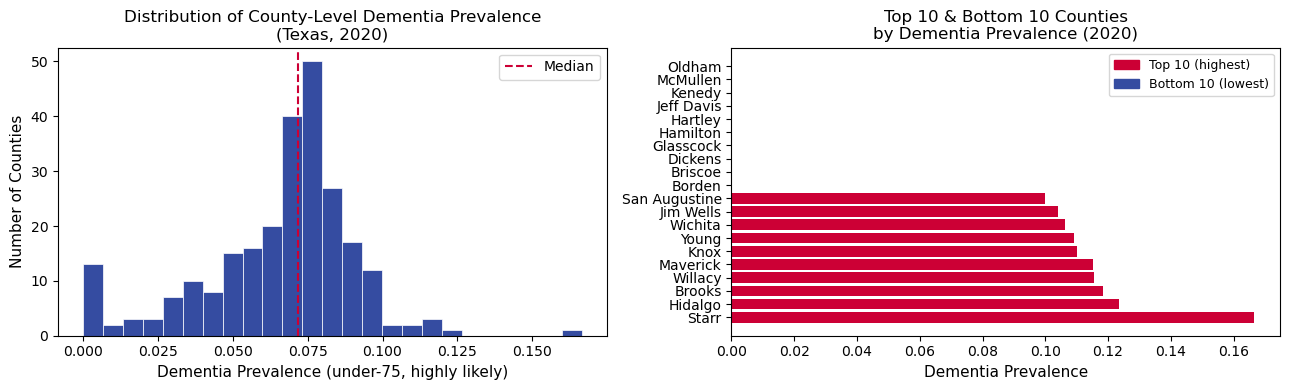

Median prevalence: 0.0719
Max: 0.1665  (Starr)
Min: 0.0000  (Borden)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(under75_highlylikely_county["dementia_prevalence"].dropna(),
             bins=25, color=SMU_BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Dementia Prevalence (under-75, highly likely)", fontsize=11)
axes[0].set_ylabel("Number of Counties", fontsize=11)
axes[0].set_title("Distribution of County-Level Dementia Prevalence\n(Texas, 2020)", fontsize=12)
axes[0].axvline(under75_highlylikely_county["dementia_prevalence"].median(),
                color=SMU_RED, linestyle="--", linewidth=1.5, label="Median")
axes[0].legend()

# Top/bottom 10 counties
top10 = under75_highlylikely_county.nlargest(10, "dementia_prevalence")
bot10 = under75_highlylikely_county.nsmallest(10, "dementia_prevalence")
plot_df = pd.concat([top10, bot10]).drop_duplicates()
colors = [SMU_RED if v >= top10["dementia_prevalence"].min() else SMU_GREEN_BLUE
          for v in plot_df["dementia_prevalence"]]
axes[1].barh(plot_df["County_Name"], plot_df["dementia_prevalence"], color=colors)
axes[1].set_xlabel("Dementia Prevalence", fontsize=11)
axes[1].set_title("Top 10 & Bottom 10 Counties\nby Dementia Prevalence (2020)", fontsize=12)
hi_p = mpatches.Patch(color=SMU_RED, label="Top 10 (highest)")
lo_p = mpatches.Patch(color=SMU_BLUE, label="Bottom 10 (lowest)")
axes[1].legend(handles=[hi_p, lo_p], fontsize=9)

plt.tight_layout()
plt.savefig("eda_dementia_prevalence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median prevalence: {under75_highlylikely_county['dementia_prevalence'].median():.4f}")
print(f"Max: {under75_highlylikely_county['dementia_prevalence'].max():.4f}  ({top10.iloc[0]['County_Name']})")
print(f"Min: {under75_highlylikely_county['dementia_prevalence'].min():.4f}  ({bot10.iloc[0]['County_Name']})")


### 5.2 Distribution of Lithium Concentrations Across Texas Counties

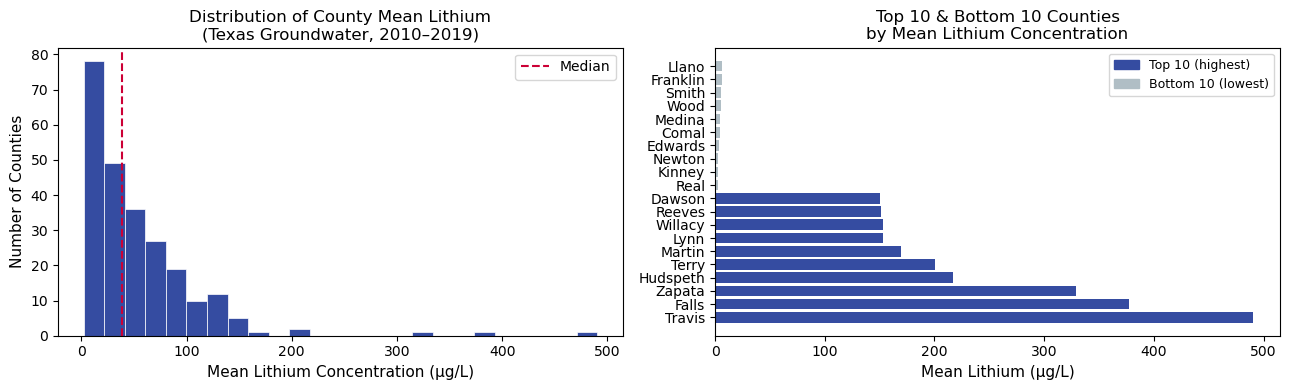

Counties with lithium data: 242
Median lithium: 38.31 µg/L


In [7]:
lithium_means = (
    parameter_county_features[parameter_county_features["Parameter"] == "LITHIUM"]
    [["County_Name", "mean_value", "median_value", "n_samples"]]
    .rename(columns={"mean_value": "lithium_mean", "median_value": "lithium_median"})
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(lithium_means["lithium_mean"].dropna(), bins=25,
             color=SMU_BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Mean Lithium Concentration (µg/L)", fontsize=11)
axes[0].set_ylabel("Number of Counties", fontsize=11)
axes[0].set_title("Distribution of County Mean Lithium\n(Texas Groundwater, 2010–2019)", fontsize=12)
axes[0].axvline(lithium_means["lithium_mean"].median(),
                color=SMU_RED, linestyle="--", linewidth=1.5, label="Median")
axes[0].legend()

top_li = lithium_means.nlargest(10, "lithium_mean")
bot_li = lithium_means.nsmallest(10, "lithium_mean")
plot_li = pd.concat([top_li, bot_li]).drop_duplicates()
colors_li = [SMU_BLUE if v >= top_li["lithium_mean"].min() else "#B0BEC5"
             for v in plot_li["lithium_mean"]]
axes[1].barh(plot_li["County_Name"], plot_li["lithium_mean"], color=colors_li)
axes[1].set_xlabel("Mean Lithium (µg/L)", fontsize=11)
axes[1].set_title("Top 10 & Bottom 10 Counties\nby Mean Lithium Concentration", fontsize=12)
hi_p = mpatches.Patch(color=SMU_BLUE, label="Top 10 (highest)")
lo_p = mpatches.Patch(color="#B0BEC5", label="Bottom 10 (lowest)")
axes[1].legend(handles=[hi_p, lo_p], fontsize=9)

plt.tight_layout()
plt.savefig("eda_lithium_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Counties with lithium data: {len(lithium_means)}")
print(f"Median lithium: {lithium_means['lithium_mean'].median():.2f} µg/L")


### 5.3 Bivariate: Lithium vs. Dementia Prevalence (All Counties with Data)

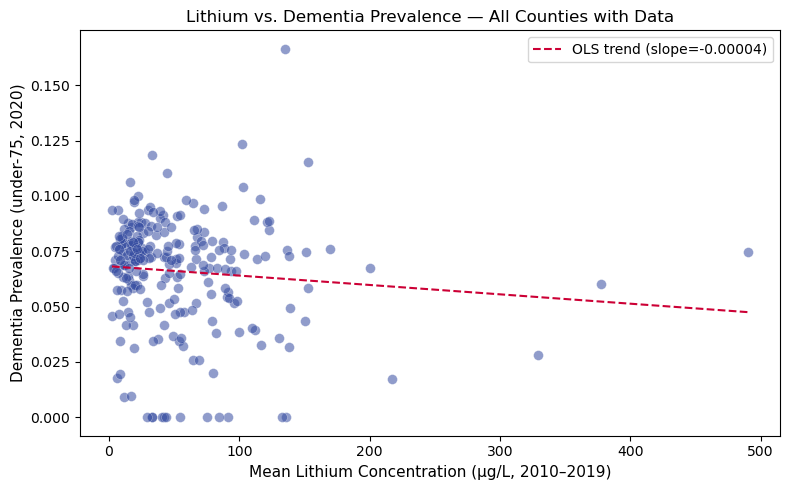

Pearson correlation (lithium mean vs dementia prevalence): r = -0.0947
N counties with both measures: 240


In [8]:
eda_merge = (
    lithium_means
    .merge(
        under75_highlylikely_county.rename(columns={"FIPS_COUNTY": "FIPS_Code"}),
        on="County_Name", how="inner"
    )
    .dropna(subset=["lithium_mean", "dementia_prevalence"])
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(eda_merge["lithium_mean"], eda_merge["dementia_prevalence"],
           alpha=0.55, color=SMU_BLUE, edgecolors="white", linewidth=0.3, s=50)

m, b = np.polyfit(eda_merge["lithium_mean"], eda_merge["dementia_prevalence"], 1)
x_line = np.linspace(eda_merge["lithium_mean"].min(), eda_merge["lithium_mean"].max(), 100)
ax.plot(x_line, m * x_line + b, color=SMU_RED, linewidth=1.5,
        linestyle="--", label=f"OLS trend (slope={m:.5f})")

ax.set_xlabel("Mean Lithium Concentration (µg/L, 2010–2019)", fontsize=11)
ax.set_ylabel("Dementia Prevalence (under-75, 2020)", fontsize=11)
ax.set_title("Lithium vs. Dementia Prevalence — All Counties with Data", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("eda_lithium_vs_dementia_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

corr = eda_merge["lithium_mean"].corr(eda_merge["dementia_prevalence"])
print(f"Pearson correlation (lithium mean vs dementia prevalence): r = {corr:.4f}")
print(f"N counties with both measures: {len(eda_merge)}")


### 5.4 Data Coverage: Lithium Sample Counts by County

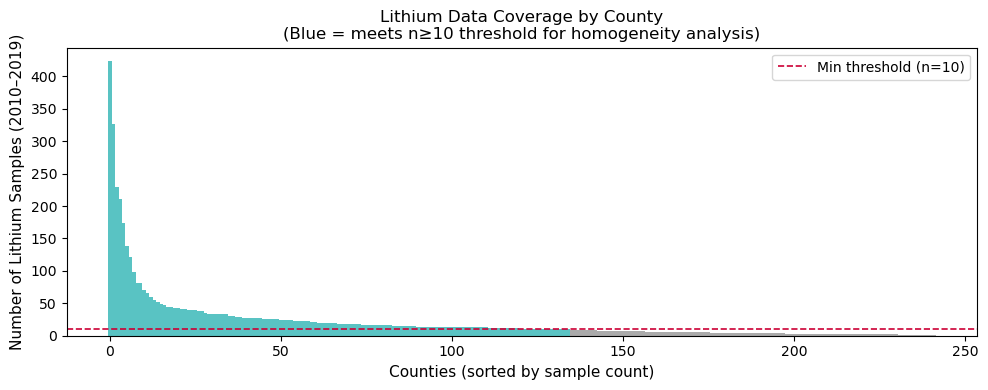

Counties with ≥10 lithium samples: 135 of 242


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
sample_counts = lithium_means.sort_values("n_samples", ascending=False)
colors_n = [SMU_GREEN_BLUE if n >= 10 else "#AAAAAA" for n in sample_counts["n_samples"]]
ax.bar(range(len(sample_counts)), sample_counts["n_samples"], color=colors_n, width=1.0)
ax.axhline(10, color=SMU_RED, linestyle="--", linewidth=1.2, label="Min threshold (n=10)")
ax.set_xlabel("Counties (sorted by sample count)", fontsize=11)
ax.set_ylabel("Number of Lithium Samples (2010–2019)", fontsize=11)
ax.set_title("Lithium Data Coverage by County\n(Blue = meets n≥10 threshold for homogeneity analysis)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("eda_lithium_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
n_sufficient = (sample_counts["n_samples"] >= 10).sum()
print(f"Counties with ≥10 lithium samples: {n_sufficient} of {len(sample_counts)}")


### 5.5 All Minerals — Statewide Distribution Overview

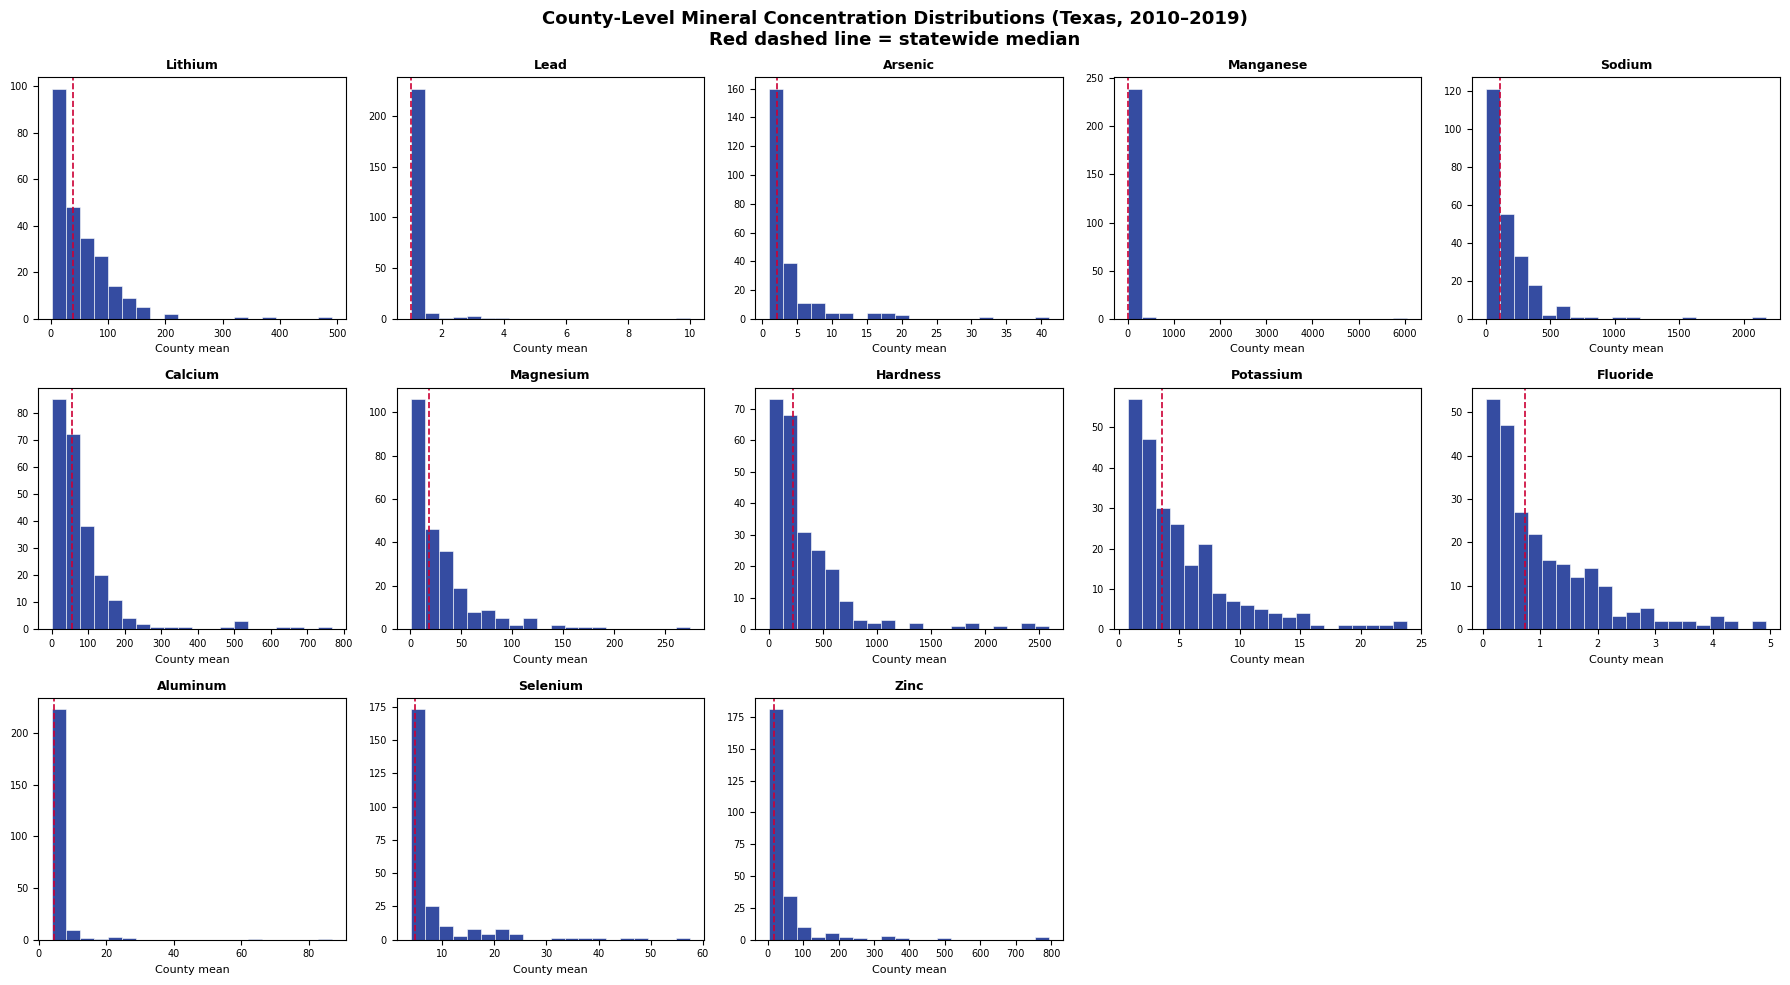

In [10]:
# Quick overview of all 13 mineral distributions (statewide)
mineral_order = [
    "LITHIUM", "LEAD", "ARSENIC", "MANGANESE",
    "SODIUM", "CALCIUM", "MAGNESIUM", "HARDNESS",
    "POTASSIUM", "FLUORIDE", "ALUMINUM", "SELENIUM", "ZINC"
]

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, param in enumerate(mineral_order):
    sub = parameter_county_features[parameter_county_features["Parameter"] == param]["mean_value"].dropna()
    axes[i].hist(sub, bins=20, color=SMU_BLUE, edgecolor="white", linewidth=0.4)
    axes[i].axvline(sub.median(), color=SMU_RED, linestyle="--", linewidth=1.2)
    axes[i].set_title(param.title(), fontsize=9, fontweight="bold")
    axes[i].set_xlabel("County mean", fontsize=8)
    axes[i].tick_params(labelsize=7)

# Hide unused subplots
for j in range(len(mineral_order), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("County-Level Mineral Concentration Distributions (Texas, 2010–2019)\nRed dashed line = statewide median",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_all_minerals_overview.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.6 Correlation Matrix Among Key Minerals

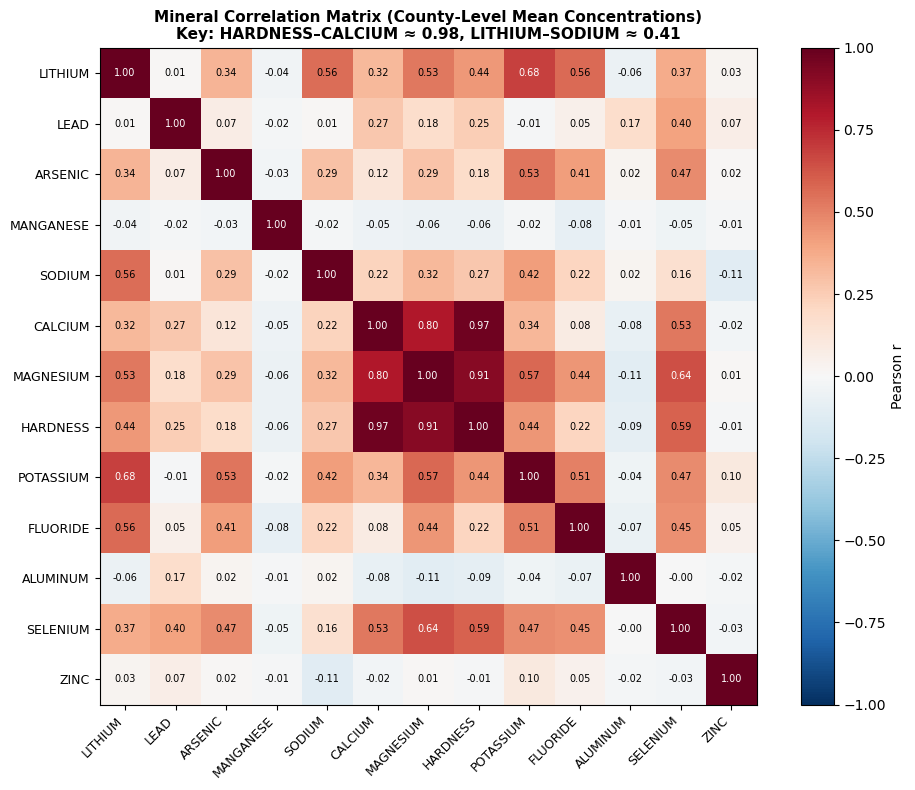

In [11]:
# Pivot mineral means to wide for correlation analysis
wide_corr = (
    parameter_county_features
        .pivot_table(index="County_Name", columns="Parameter", values="mean_value", aggfunc="first")
        .reset_index()
)
wide_corr.columns.name = None

corr_params = [p for p in mineral_order if p in wide_corr.columns]
corr_matrix = wide_corr[corr_params].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_params)))
ax.set_yticks(range(len(corr_params)))
ax.set_xticklabels(corr_params, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_params, fontsize=9)
for i in range(len(corr_params)):
    for j in range(len(corr_params)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 0.6 else "black")
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Mineral Correlation Matrix (County-Level Mean Concentrations)\n"
             "Key: HARDNESS–CALCIUM ≈ 0.98, LITHIUM–SODIUM ≈ 0.41",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 6: Exposure Homogeneity Classification <a id='section-6'></a>

**The core methodological insight:** County-mean lithium averages together exposed and unexposed residents when wells vary widely within a county. This dilutes the signal to zero even if a real biological effect exists.

We identify **homogeneous counties** where groundwater lithium is internally consistent:
- ≥10 lithium samples (data density)
- ≥70% of wells fall at or above the statewide 75th percentile (HIGH) OR ≤ statewide 25th percentile (LOW)
- Coefficient of variation ≤ 0.5 (low internal variability)

In these counties, county-mean lithium is a meaningful proxy for individual-level exposure.


In [12]:
# Use the full pre-2020 window (2000-2019) to maximize sample size for classification
lithium_wells = water_clean[
    water_clean["ParameterDescription"].str.contains("LITHIUM", case=False)
].copy()
lithium_wells = lithium_wells[lithium_wells["Date"].dt.year.between(2000, 2019)]

# Statewide percentile thresholds
lithium_p25 = lithium_wells["ParameterValue"].quantile(0.25)
lithium_p75 = lithium_wells["ParameterValue"].quantile(0.75)
print(f"Statewide lithium p25 = {lithium_p25:.2f} µg/L")
print(f"Statewide lithium p75 = {lithium_p75:.2f} µg/L")

# County-level dispersion profile
county_lithium_profile = (
    lithium_wells
        .groupby(["FIPS_Code", "County_Name"])
        .agg(
            n_wells      =("ParameterValue", "count"),
            mean_lithium =("ParameterValue", "mean"),
            std_lithium  =("ParameterValue", "std"),
            q25          =("ParameterValue", lambda x: x.quantile(0.25)),
            q75          =("ParameterValue", lambda x: x.quantile(0.75)),
            pct_high     =("ParameterValue", lambda x: (x >= lithium_p75).mean()),
            pct_low      =("ParameterValue", lambda x: (x <= lithium_p25).mean())
        )
        .reset_index()
)
county_lithium_profile["iqr"] = county_lithium_profile["q75"] - county_lithium_profile["q25"]
county_lithium_profile["cv"]  = county_lithium_profile["std_lithium"] / county_lithium_profile["mean_lithium"]

# Apply homogeneity criteria
homogeneous_lithium_counties = county_lithium_profile[
    (county_lithium_profile["n_wells"] >= 10) &
    (
        (county_lithium_profile["pct_high"] >= 0.70) |
        (county_lithium_profile["pct_low"]  >= 0.70)
    ) &
    (county_lithium_profile["cv"] <= 0.5)
].copy()

homogeneous_lithium_counties["lithium_group"] = np.where(
    homogeneous_lithium_counties["pct_high"] >= 0.70, "HIGH", "LOW"
)

print(f"\nHomogeneous lithium counties: {homogeneous_lithium_counties.shape[0]}")
print(homogeneous_lithium_counties["lithium_group"].value_counts().to_string())
display_cols = ["County_Name","lithium_group","mean_lithium","cv","n_wells","pct_high","pct_low"]
print()
print(homogeneous_lithium_counties[display_cols].to_string(index=False))


Statewide lithium p25 = 6.80 µg/L
Statewide lithium p75 = 65.00 µg/L

Homogeneous lithium counties: 14
lithium_group
HIGH    12
LOW      2

County_Name lithium_group  mean_lithium       cv  n_wells  pct_high  pct_low
     Bailey          HIGH    126.260000 0.478250       35  0.828571      0.0
    Briscoe          HIGH    104.407143 0.368312       14  0.785714      0.0
     Dallas          HIGH     73.276190 0.290539       21  0.714286      0.0
      Floyd          HIGH     97.861538 0.372890       39  0.897436      0.0
       Hale          HIGH     79.879487 0.208759       39  0.846154      0.0
   Hardeman          HIGH     82.420000 0.314775       10  0.700000      0.0
    Hockley          HIGH    134.451282 0.334023       39  1.000000      0.0
     Kenedy          HIGH     69.210000 0.102724       10  0.700000      0.0
     Kinney           LOW      2.411364 0.248912       22  0.000000      1.0
    Lubbock          HIGH    130.544118 0.490927       34  0.823529      0.0
  Ochiltree  

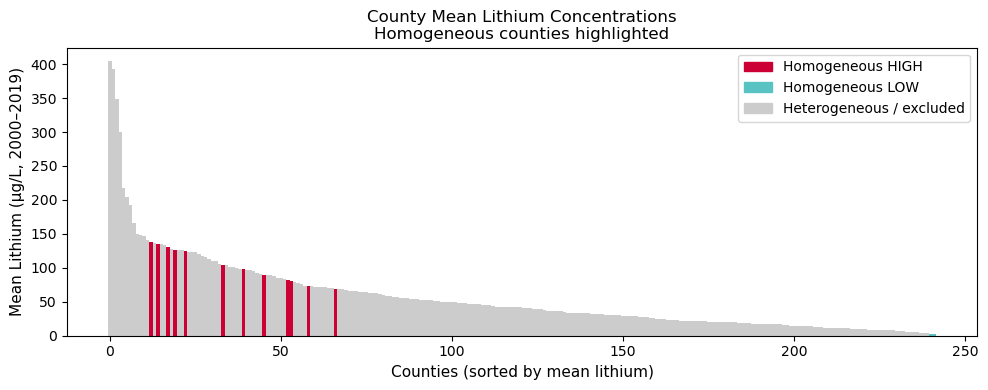

In [13]:
# Visualize: where do homogeneous counties fall in the lithium distribution?
fig, ax = plt.subplots(figsize=(10, 4))

all_means = county_lithium_profile.copy()
homog_names = set(homogeneous_lithium_counties["County_Name"])

colors_h = []
sorted_df = all_means.sort_values("mean_lithium", ascending=False)
for _, row in sorted_df.iterrows():
    if row["County_Name"] in homog_names:
        group = homogeneous_lithium_counties.loc[
            homogeneous_lithium_counties["County_Name"] == row["County_Name"], "lithium_group"
        ].values[0]
        colors_h.append(SMU_RED if group == "HIGH" else SMU_GREEN_BLUE)
    else:
        colors_h.append("#CCCCCC")

ax.bar(range(len(sorted_df)), sorted_df["mean_lithium"], color=colors_h, width=1.0)
ax.set_xlabel("Counties (sorted by mean lithium)", fontsize=11)
ax.set_ylabel("Mean Lithium (µg/L, 2000–2019)", fontsize=11)
ax.set_title("County Mean Lithium Concentrations\nHomogeneous counties highlighted", fontsize=12)
hi_p = mpatches.Patch(color=SMU_RED, label="Homogeneous HIGH")
lo_p = mpatches.Patch(color=SMU_GREEN_BLUE, label="Homogeneous LOW")
gr_p = mpatches.Patch(color="#CCCCCC", label="Heterogeneous / excluded")
ax.legend(handles=[hi_p, lo_p, gr_p])
plt.tight_layout()
plt.savefig("homogeneity_classification.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 7: Load Texas County GIS Boundaries <a id='section-7'></a>

We pull Census TIGER shapefiles directly from the Census Bureau to define geographic boundaries for all choropleth maps. We also build the wide-format water quality table and merge everything onto the GeoDataFrame.

Loading Texas county boundaries from Census TIGER...
Texas counties loaded: 254


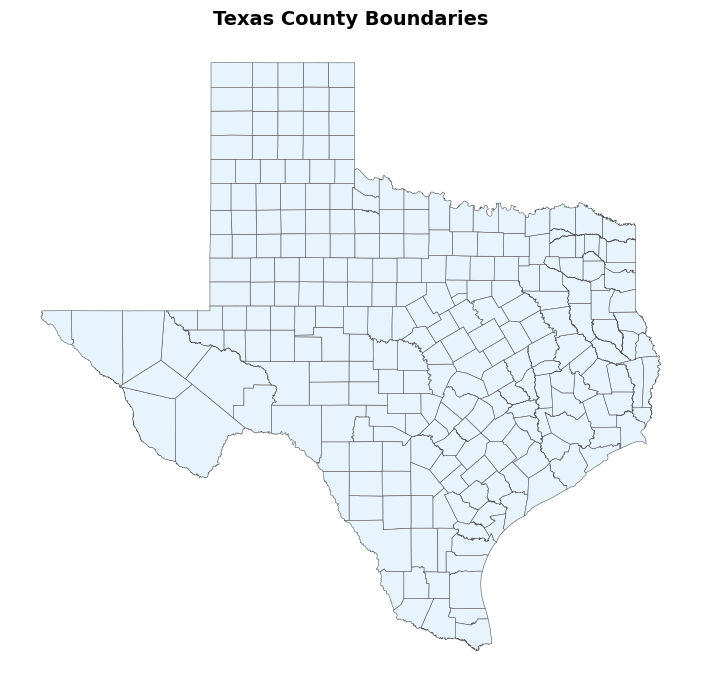

In [14]:
import geopandas as gpd

# ── Load TIGER shapefiles ─────────────────────────────────────────────────────
print("Loading Texas county boundaries from Census TIGER...")
counties_us = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
)
tx_counties = counties_us[counties_us["STATEFP"] == "48"].copy()
tx_counties["FIPS_Code"] = tx_counties["COUNTYFP"].astype(int)
tx_counties = tx_counties.drop(columns=["NAME"], errors="ignore")

print(f"Texas counties loaded: {tx_counties.shape[0]}")

# Quick base map
fig, ax = plt.subplots(figsize=(8, 7))
tx_counties.plot(ax=ax, color="#E8F4FD", edgecolor="#555555", linewidth=0.4)
ax.set_title("Texas County Boundaries", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("texas_base_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# ── Aggregate minerals to county-level means (all pre-2020 samples) ──────────
keep_params_gis = {
    "LITHIUM, DISSOLVED (UG/L AS LI)":             ("lithium",    "µg/L"),
    "LEAD, DISSOLVED (UG/L AS PB)":                ("lead",       "µg/L"),
    "ARSENIC, DISSOLVED (UG/L AS AS)":             ("arsenic",    "µg/L"),
    "MANGANESE, DISSOLVED (UG/L AS MN)":           ("manganese",  "µg/L"),
    "SODIUM, DISSOLVED (MG/L AS NA)":              ("sodium",     "mg/L"),
    "CALCIUM, DISSOLVED (MG/L AS CA)":             ("calcium",    "mg/L"),
    "MAGNESIUM, DISSOLVED (MG/L AS MG)":           ("magnesium",  "mg/L"),
    "HARDNESS, TOTAL, CALCULATED (MG/L AS CACO3)": ("hardness",   "mg/L as CaCO₃"),
    "POTASSIUM, DISSOLVED (MG/L AS K)":            ("potassium",  "mg/L"),
    "FLUORIDE, DISSOLVED (MG/L AS F)":             ("fluoride",   "mg/L"),
    "ALUMINUM, DISSOLVED (UG/L AS AL)":            ("aluminum",   "µg/L"),
    "SELENIUM, DISSOLVED (UG/L AS SE)":            ("selenium",   "µg/L"),
    "ZINC, DISSOLVED (UG/L AS ZN)":                ("zinc",       "µg/L"),
}

param_short_map = {full: short for full, (short, _) in keep_params_gis.items()}
param_unit_map  = {short: unit  for _, (short, unit) in keep_params_gis.items()}

water_filtered = water_clean[water_clean["ParameterDescription"].isin(keep_params_gis.keys())].copy()
water_filtered["param_short"] = water_filtered["ParameterDescription"].map(param_short_map)

county_means_wide = (
    water_filtered
        .groupby(["County_Name", "FIPS_Code", "param_short"])["ParameterValue"]
        .mean()
        .reset_index()
        .rename(columns={"ParameterValue": "mean_value"})
        .pivot_table(index=["County_Name","FIPS_Code"], columns="param_short", values="mean_value", aggfunc="first")
        .reset_index()
)
county_means_wide.columns.name = None

# ── Merge dementia prevalence ─────────────────────────────────────────────────
dementia_gis = under75_highlylikely_county.rename(columns={"FIPS_COUNTY": "FIPS_Code"})

# ── Merge everything onto GeoDataFrame ───────────────────────────────────────
wide_merge = county_means_wide.drop(columns=["County_Name"], errors="ignore")
tx_mapped = tx_counties.merge(wide_merge, on="FIPS_Code", how="left")
tx_mapped = tx_mapped.merge(
    dementia_gis[["FIPS_Code","dementia_prevalence","prev_cnt","bene_cnt"]],
    on="FIPS_Code", how="left"
)

print(f"tx_mapped shape: {tx_mapped.shape}")
print(f"Counties with lithium data:  {tx_mapped['lithium'].notna().sum()}")
print(f"Counties with dementia data: {tx_mapped['dementia_prevalence'].notna().sum()}")


tx_mapped shape: (254, 35)
Counties with lithium data:  242
Counties with dementia data: 252


---
## Section 8: Choropleth Maps — Primary Study Variables <a id='section-8'></a>

A reusable function produces publication-quality Texas county choropleths for any variable. Color scales are clipped at the 95th percentile to prevent extreme outliers from washing out the map.


In [16]:
def plot_texas_choropleth(
    variable,
    title=None,
    unit=None,
    cmap="YlOrRd",
    clip_pct=95,
    figsize=(11, 8),
    save=True
):
    """
    Plot a county-level choropleth map for any variable in tx_mapped.

    Parameters
    ----------
    variable : str     — column name in tx_mapped
    title    : str     — map title (auto-generated if None)
    unit     : str     — colorbar label (auto-detected from param_unit_map if None)
    cmap     : str     — matplotlib colormap
    clip_pct : int     — clip color scale at this percentile (default 95)
    figsize  : tuple
    save     : bool    — save PNG if True
    """
    if variable not in tx_mapped.columns:
        raise ValueError(f"Variable '{variable}' not in tx_mapped.")

    data = tx_mapped[variable]
    n_with_data = data.notna().sum()
    n_total = len(tx_mapped)

    vmax = np.nanpercentile(data, clip_pct)
    vmin = np.nanpercentile(data, 2)

    if title is None:
        label = variable.replace("_", " ").title()
        if variable == "dementia_prevalence":
            label = "Dementia Prevalence (Under-75, Highly Likely, 2020)"
        title = f"Texas Counties — {label}"

    if unit is None:
        unit = param_unit_map.get(variable, "")

    fig, ax = plt.subplots(figsize=figsize)

    tx_mapped[data.isna()].plot(ax=ax, color="#DDDDDD", edgecolor="#888888", linewidth=0.3)
    tx_mapped[data.notna()].plot(
        column=variable, ax=ax, cmap=cmap,
        vmin=vmin, vmax=vmax,
        edgecolor="#555555", linewidth=0.3, legend=False
    )

    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(unit if unit else variable, fontsize=11)
    if np.nanpercentile(data, 99) > vmax * 1.1:
        cbar.ax.set_title(f"(clipped at\n{clip_pct}th pctile)", fontsize=8, pad=4)

    gray_patch = mpatches.Patch(color="#DDDDDD", label=f"No data ({n_total - n_with_data} counties)")
    ax.legend(handles=[gray_patch], loc="lower left", fontsize=9)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=10)
    ax.axis("off")

    fig.text(0.13, 0.08,
             f"Data available for {n_with_data} of {n_total} Texas counties | "
             f"Source: TWDB Groundwater Database (pre-2020)",
             fontsize=8, color="#555555")

    plt.tight_layout()
    if save:
        fname = f"map_{variable}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {fname}")
    plt.show()


### 8.1 Lithium Concentration

Lithium is the primary exposure variable. Concentrations vary substantially across Texas due to differences in underlying geology and aquifer systems.

Saved: map_lithium.png


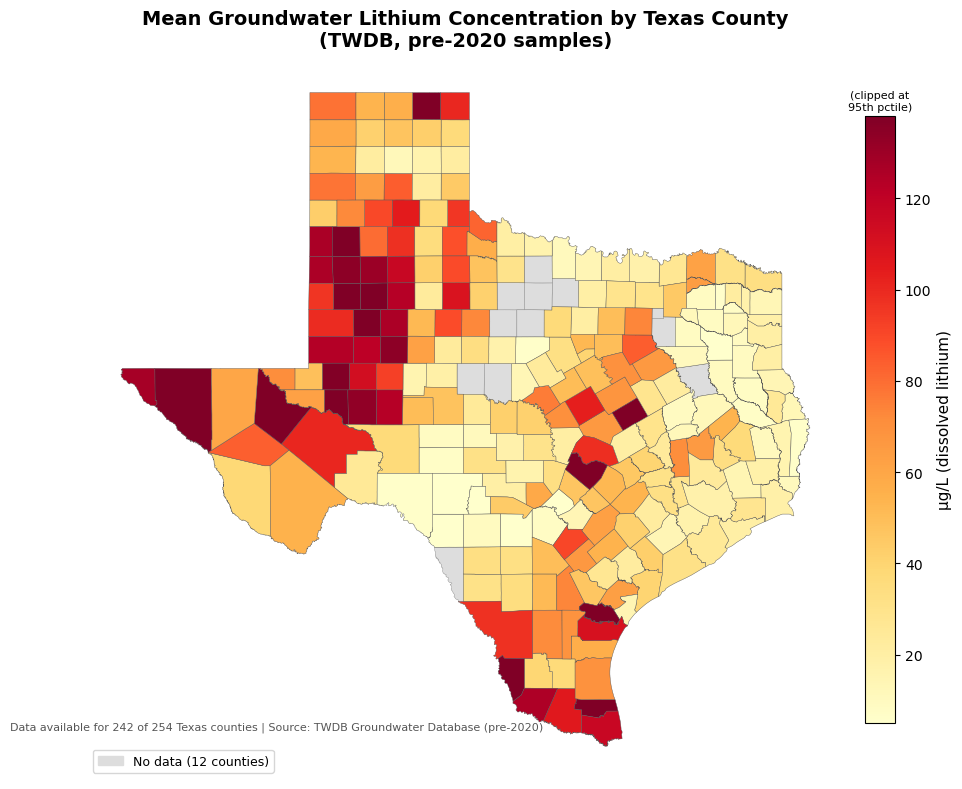

In [17]:
plot_texas_choropleth(
    "lithium",
    title="Mean Groundwater Lithium Concentration by Texas County\n(TWDB, pre-2020 samples)",
    unit="µg/L (dissolved lithium)",
    cmap="YlOrRd"
)


### 8.2 Dementia Prevalence

The outcome variable — county-level prevalence among Medicare beneficiaries under 75 classified as highly likely dementia (NORC DataHub, 2020).

Saved: map_dementia_prevalence.png


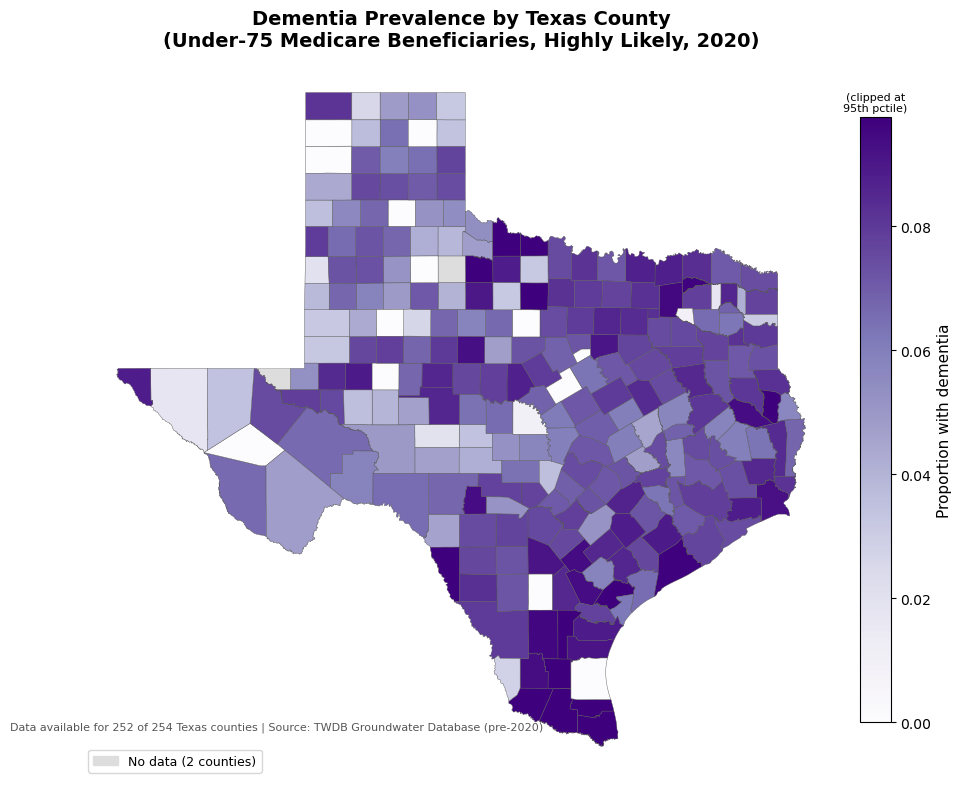

In [18]:
plot_texas_choropleth(
    "dementia_prevalence",
    title="Dementia Prevalence by Texas County\n(Under-75 Medicare Beneficiaries, Highly Likely, 2020)",
    unit="Proportion with dementia",
    cmap="Purples"
)


### 8.3 Side-by-Side: Lithium and Dementia

A direct visual comparison of the two primary variables for inclusion in the paper.

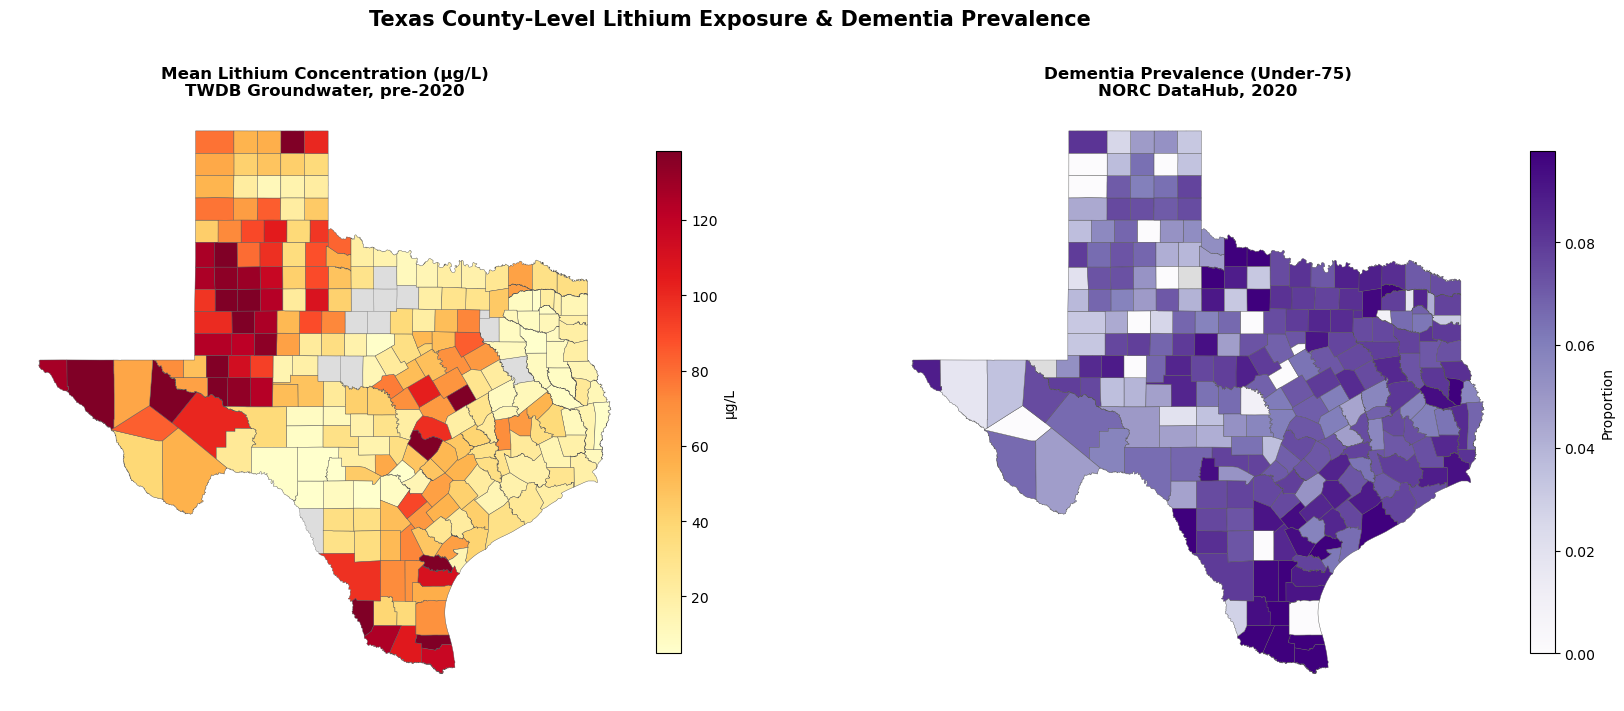

Saved: map_lithium_vs_dementia_sidebyside.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

def _choropleth_ax(ax, variable, title, unit, cmap, clip_pct=95):
    data = tx_mapped[variable]
    vmax = np.nanpercentile(data, clip_pct)
    vmin = np.nanpercentile(data, 2)
    tx_mapped[data.isna()].plot(ax=ax, color="#DDDDDD", edgecolor="#888888", linewidth=0.3)
    tx_mapped[data.notna()].plot(
        column=variable, ax=ax, cmap=cmap,
        vmin=vmin, vmax=vmax, edgecolor="#555555", linewidth=0.3, legend=False
    )
    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(unit, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")

_choropleth_ax(axes[0], "lithium",
               "Mean Lithium Concentration (µg/L)\nTWDB Groundwater, pre-2020",
               "µg/L", "YlOrRd")
_choropleth_ax(axes[1], "dementia_prevalence",
               "Dementia Prevalence (Under-75)\nNORC DataHub, 2020",
               "Proportion", "Purples")

fig.suptitle("Texas County-Level Lithium Exposure & Dementia Prevalence",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("map_lithium_vs_dementia_sidebyside.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map_lithium_vs_dementia_sidebyside.png")


---
## Section 9: Choropleth Maps — Co-occurring Minerals <a id='section-9'></a>

These minerals co-occur with lithium in Texas groundwater and may modify its apparent association with dementia prevalence. Sodium shares lithium's physiological transport pathways; calcium, magnesium, and hardness reflect overall water mineralization; lead, arsenic, and manganese are established neurotoxicants.


Saved: map_sodium.png


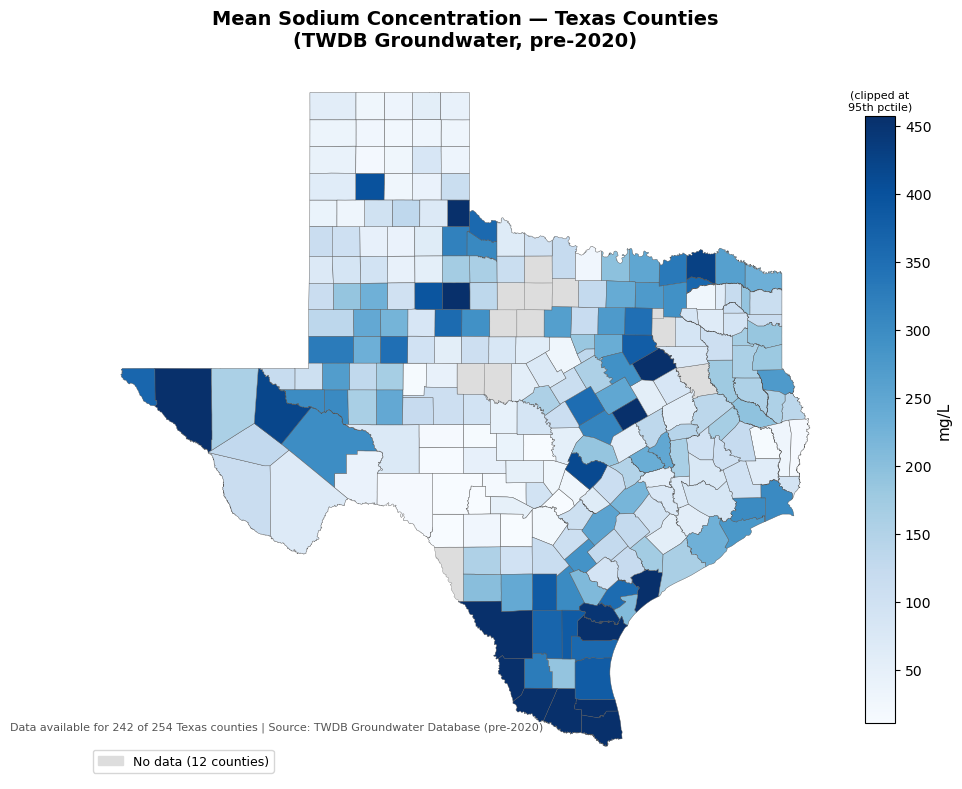

Saved: map_calcium.png


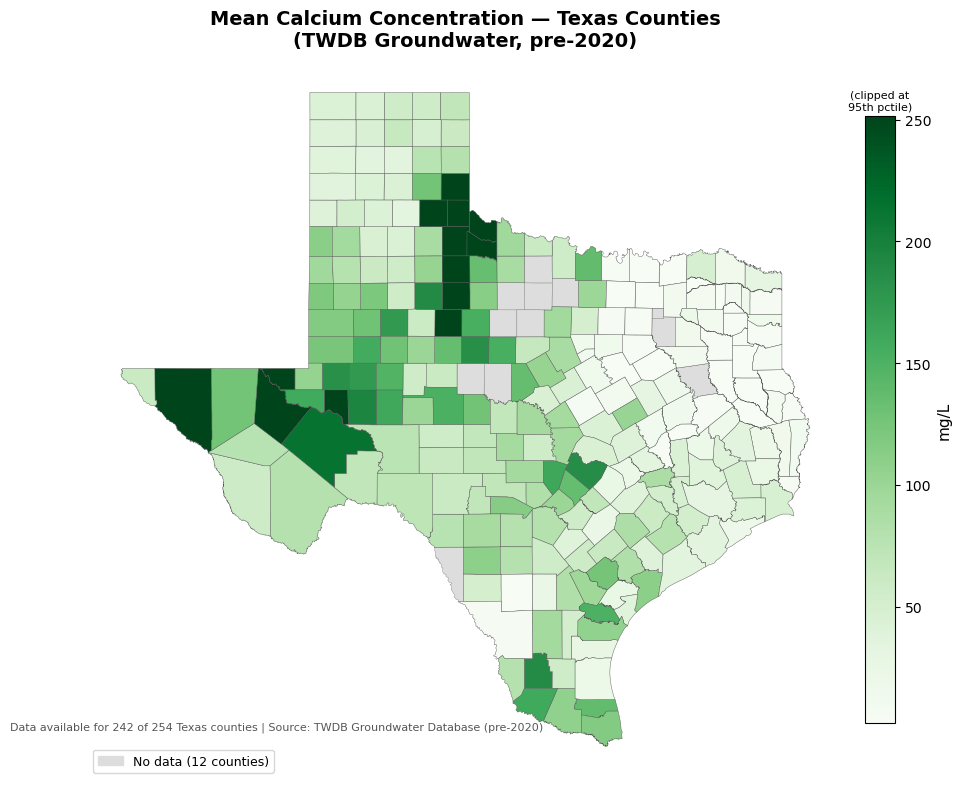

Saved: map_magnesium.png


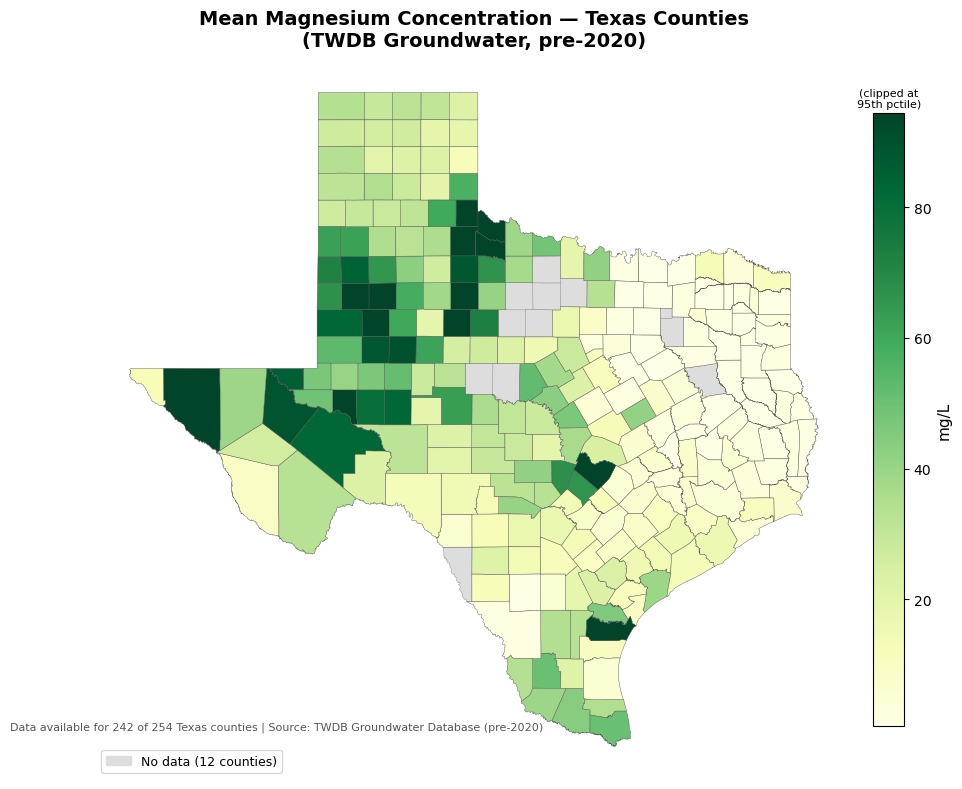

Saved: map_hardness.png


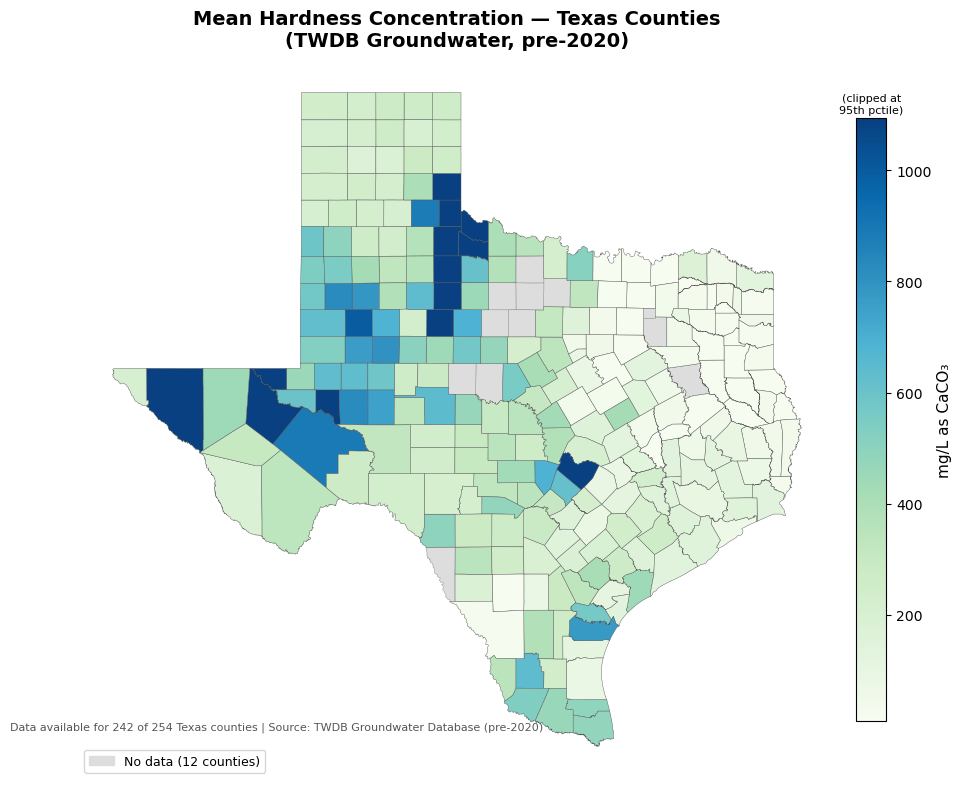

Saved: map_potassium.png


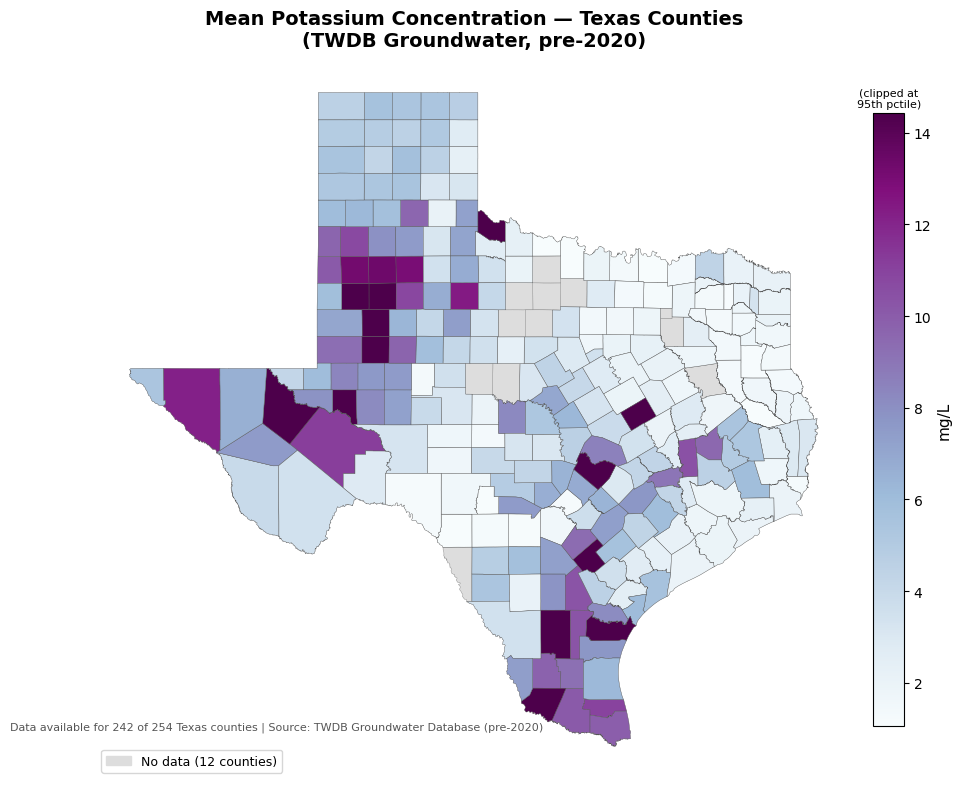

In [20]:
# Geochemical co-occurrents
for var, cmap_choice in [
    ("sodium",    "Blues"),
    ("calcium",   "Greens"),
    ("magnesium", "YlGn"),
    ("hardness",  "GnBu"),
    ("potassium", "BuPu"),
]:
    plot_texas_choropleth(
        var,
        cmap=cmap_choice,
        title=f"Mean {var.title()} Concentration — Texas Counties\n(TWDB Groundwater, pre-2020)"
    )


### Neurotoxicants

Saved: map_lead.png


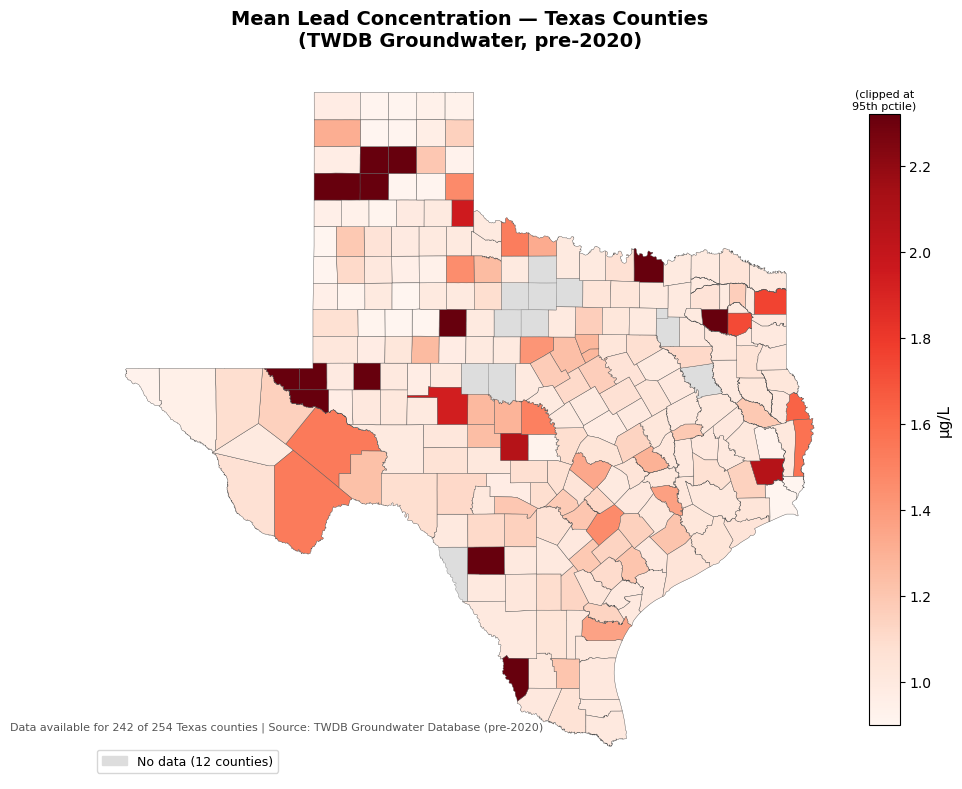

Saved: map_arsenic.png


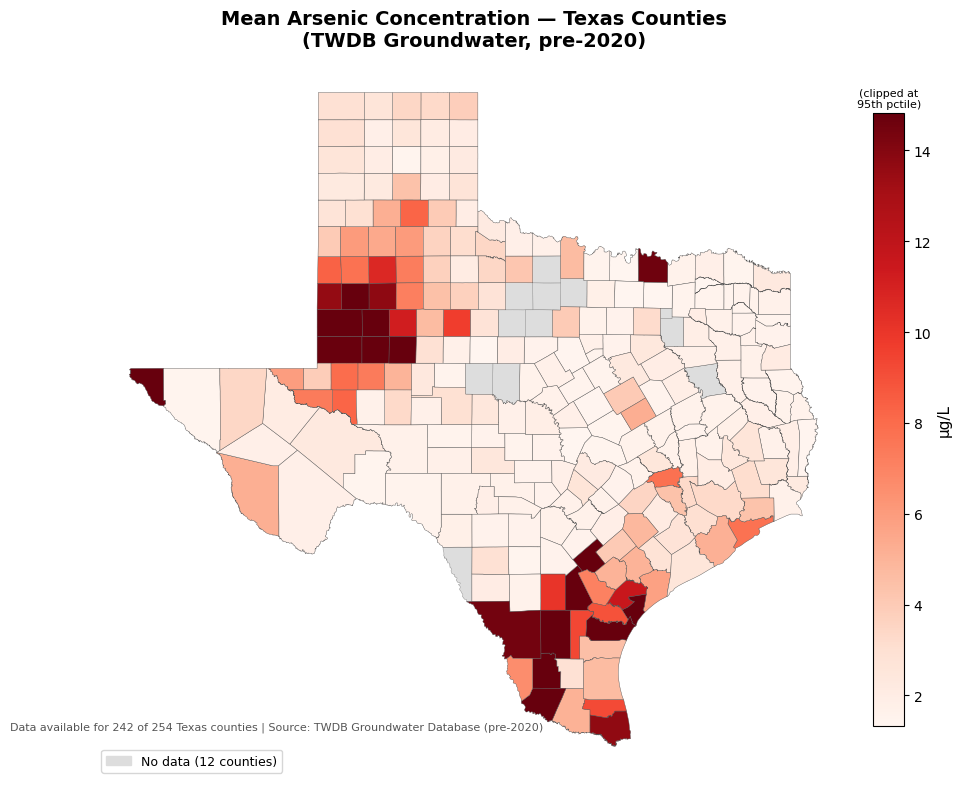

Saved: map_manganese.png


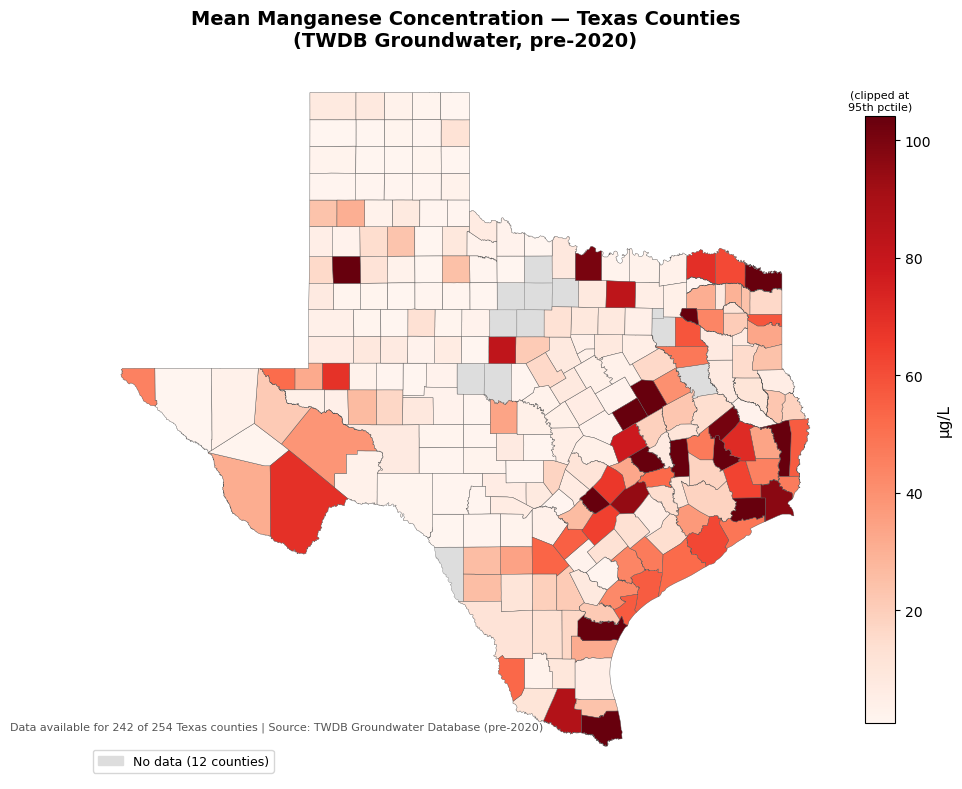

In [21]:
for var in ["lead", "arsenic", "manganese"]:
    plot_texas_choropleth(
        var,
        cmap="Reds",
        title=f"Mean {var.title()} Concentration — Texas Counties\n(TWDB Groundwater, pre-2020)"
    )


### Additional Trace Elements

Saved: map_fluoride.png


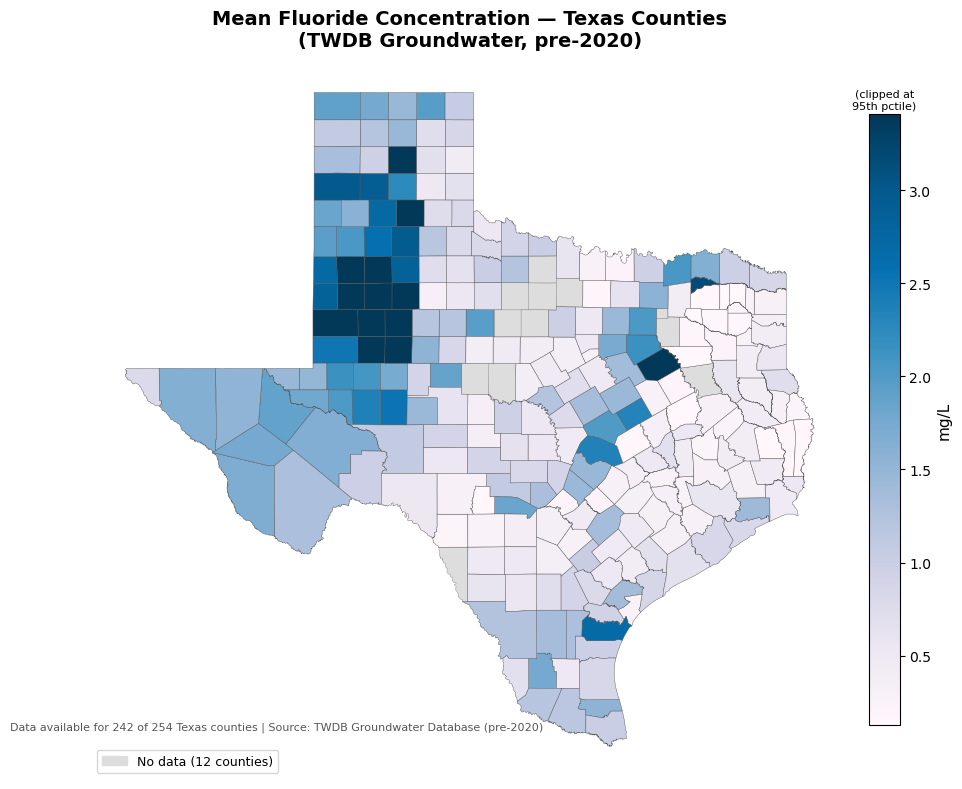

Saved: map_aluminum.png


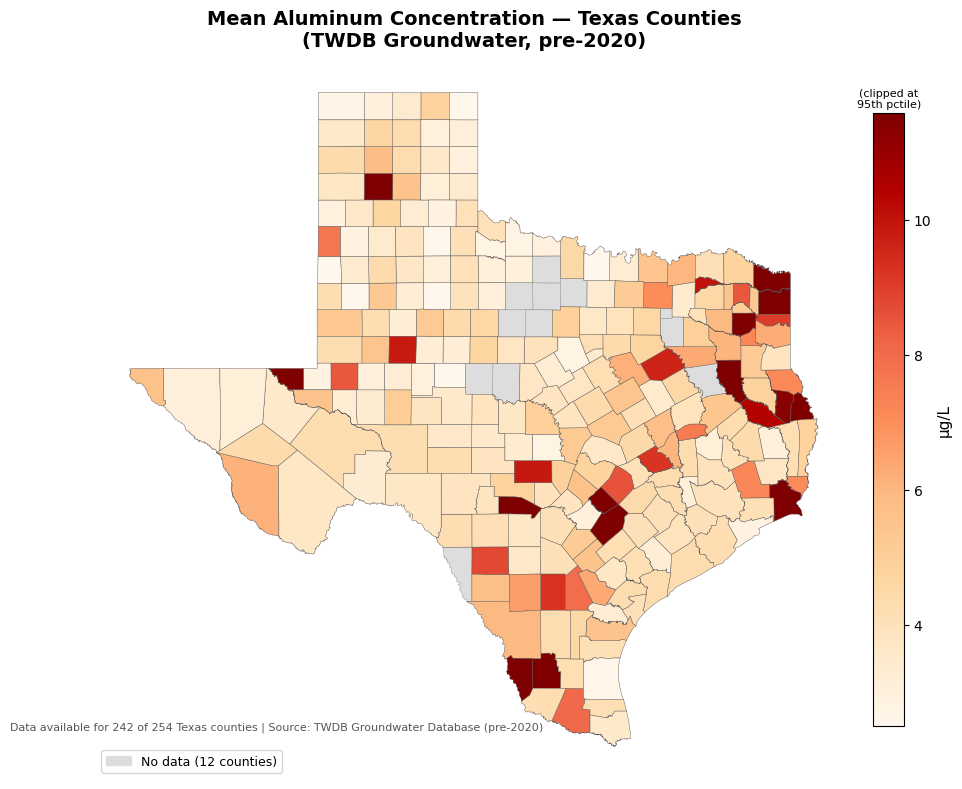

Saved: map_selenium.png


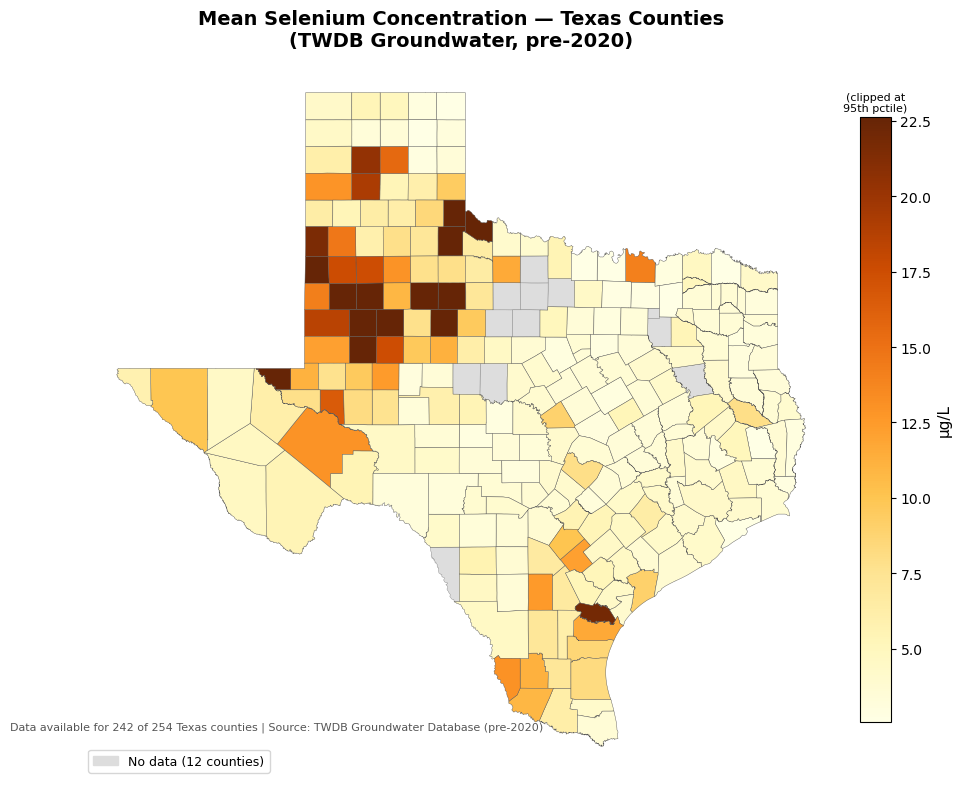

Saved: map_zinc.png


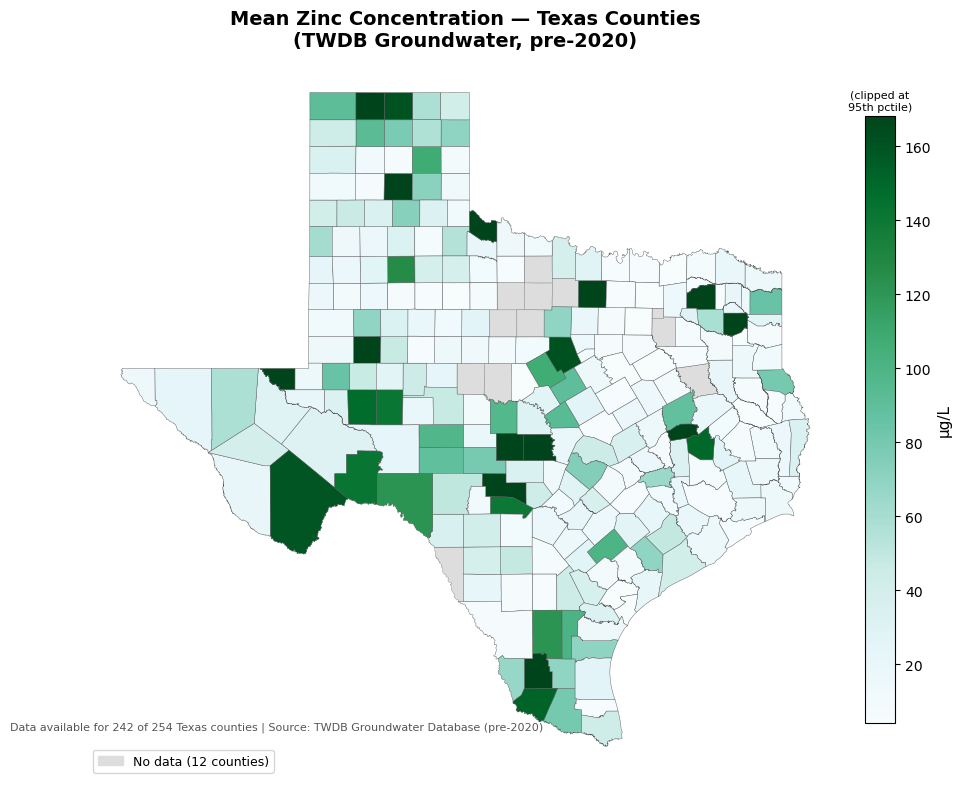

In [22]:
for var, cmap_choice in [
    ("fluoride",  "PuBu"),
    ("aluminum",  "OrRd"),
    ("selenium",  "YlOrBr"),
    ("zinc",      "BuGn"),
]:
    plot_texas_choropleth(
        var,
        cmap=cmap_choice,
        title=f"Mean {var.title()} Concentration — Texas Counties\n(TWDB Groundwater, pre-2020)"
    )


In [23]:
### Data Coverage Summary

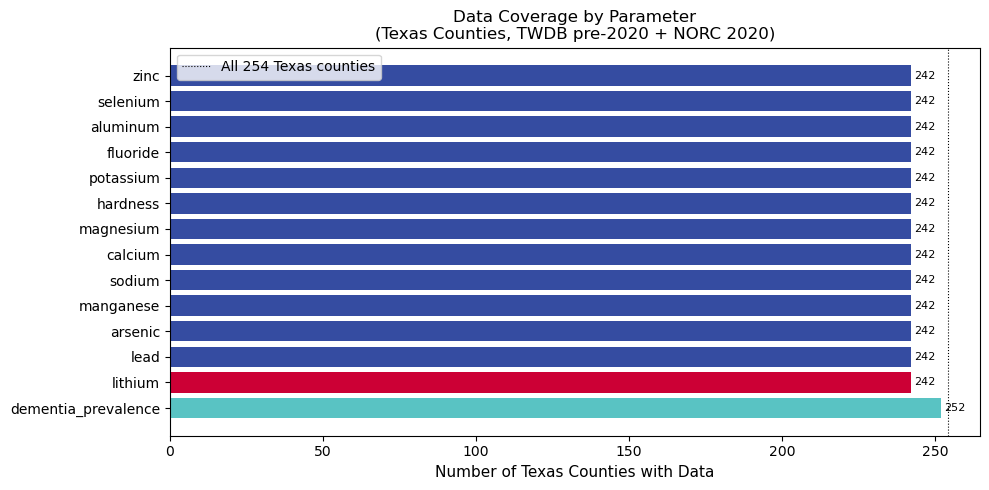

          Parameter          Unit  Counties with data  Coverage (%)
dementia_prevalence    proportion                 252          99.2
            lithium          µg/L                 242          95.3
               lead          µg/L                 242          95.3
            arsenic          µg/L                 242          95.3
          manganese          µg/L                 242          95.3
             sodium          mg/L                 242          95.3
            calcium          mg/L                 242          95.3
          magnesium          mg/L                 242          95.3
           hardness mg/L as CaCO₃                 242          95.3
          potassium          mg/L                 242          95.3
           fluoride          mg/L                 242          95.3
           aluminum          µg/L                 242          95.3
           selenium          µg/L                 242          95.3
               zinc          µg/L               

In [24]:
params_to_check = list(param_unit_map.keys()) + ["dementia_prevalence"]

coverage = []
for col in params_to_check:
    if col in tx_mapped.columns:
        n = tx_mapped[col].notna().sum()
        pct = n / len(tx_mapped) * 100
        coverage.append({
            "Parameter": col,
            "Unit": param_unit_map.get(col, "proportion"),
            "Counties with data": n,
            "Coverage (%)": round(pct, 1)
        })

coverage_df = pd.DataFrame(coverage).sort_values("Counties with data", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
col_colors = [SMU_GREEN_BLUE if c == "dementia_prevalence" else
              SMU_RED if c == "lithium" else SMU_BLUE
              for c in coverage_df["Parameter"]]
bars = ax.barh(coverage_df["Parameter"], coverage_df["Counties with data"], color=col_colors)
ax.axvline(254, color="black", linewidth=0.8, linestyle=":", label="All 254 Texas counties")
ax.set_xlabel("Number of Texas Counties with Data", fontsize=11)
ax.set_title("Data Coverage by Parameter\n(Texas Counties, TWDB pre-2020 + NORC 2020)", fontsize=12)
ax.legend()
for bar, val in zip(bars, coverage_df["Counties with data"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=8)
plt.tight_layout()
plt.savefig("data_coverage_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print(coverage_df.to_string(index=False))

---
## Section 10: Choropleth Map — Homogeneous Lithium Exposure Counties <a id='section-10'></a>

This map highlights the counties classified as having homogeneous groundwater lithium exposure — the subsample used for the primary regression analysis.

**Homogeneity criteria:**
- ≥ 10 lithium samples (2000–2019)
- ≥ 70% of wells in the statewide HIGH (≥p75) or LOW (≤p25) category
- Coefficient of variation ≤ 0.50


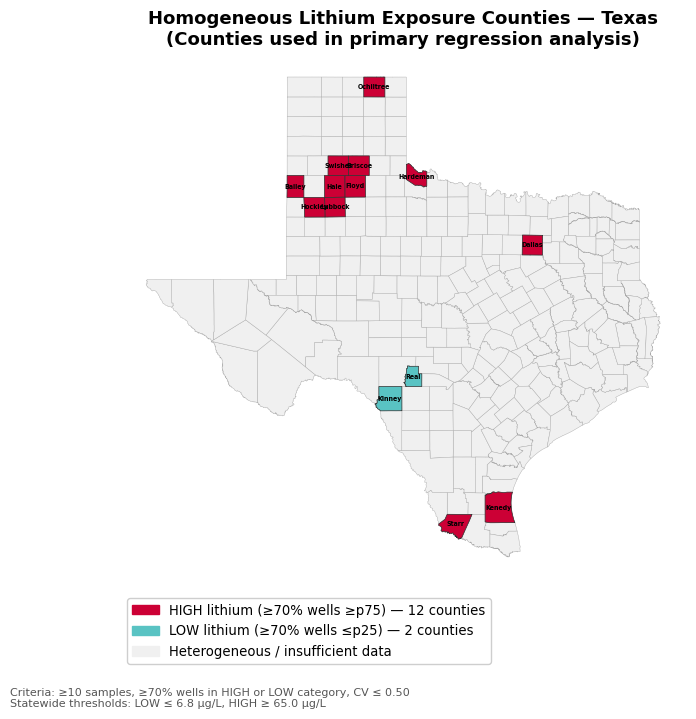


Homogeneous counties: HIGH=12, LOW=2


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Merge homogeneity classification onto GeoDataFrame
tx_homog = tx_mapped.merge(
    homogeneous_lithium_counties[["FIPS_Code", "lithium_group", "mean_lithium", "cv", "n_wells"]],
    on="FIPS_Code", how="left"
)

fig, ax = plt.subplots(figsize=(11, 8))

tx_homog.plot(ax=ax, color="#F0F0F0", edgecolor="#AAAAAA", linewidth=0.3)

high = tx_homog[tx_homog["lithium_group"] == "HIGH"]
low  = tx_homog[tx_homog["lithium_group"] == "LOW"]

high.plot(ax=ax,color=SMU_RED, edgecolor="#333333", linewidth=0.5)
low.plot(ax=ax,color=SMU_GREEN_BLUE, edgecolor="#333333", linewidth=0.5)

# County labels for homogeneous counties
for _, row in tx_homog[tx_homog["lithium_group"].notna()].iterrows():
    centroid = row["geometry"].centroid
    ax.text(
        centroid.x, centroid.y,
        row["NAMELSAD"].replace(" County", ""),
        fontsize=4.5, ha="center", va="center",
        color="black", fontweight="bold"
    )

hi_p = mpatches.Patch(color=SMU_RED,
                      label=f"HIGH lithium (≥70% wells ≥p75) — {len(high)} counties")
lo_p = mpatches.Patch(color=SMU_GREEN_BLUE,
                      label=f"LOW lithium (≥70% wells ≤p25) — {len(low)} counties")
gr_p = mpatches.Patch(color="#F0F0F0",
                      label="Heterogeneous / insufficient data")

leg = ax.legend(
    handles=[hi_p, lo_p, gr_p],
    loc="upper left",
    bbox_to_anchor=(0.0, -0.02),
    fontsize=9.5,
    framealpha=0.95,
    edgecolor="#CCCCCC",
    ncol=1
)

ax.set_title(
    "Homogeneous Lithium Exposure Counties — Texas\n"
    "(Counties used in primary regression analysis)",
    fontsize=13, fontweight="bold"
)
ax.axis("off")

criteria_text = (
    "Criteria: ≥10 samples, ≥70% wells in HIGH or LOW category, CV ≤ 0.50\n"
    f"Statewide thresholds: LOW ≤ {lithium_p25:.1f} µg/L, HIGH ≥ {lithium_p75:.1f} µg/L"
)

fig.subplots_adjust(bottom=0.22)

fig.text(
    0.155, 0.06,
    criteria_text,
    fontsize=8,
    color="#555555",
    ha="left",
    va="bottom"
)

plt.savefig("map_homogeneous_counties.png", dpi=300, pad_inches=0.2)
plt.show()

print(f"\nHomogeneous counties: HIGH={len(high)}, LOW={len(low)}")

---
## Section 11: Regression — Full County Sample <a id='section-11'></a>

We first run three nested models on the full county sample. The expected result is a near-zero lithium coefficient and very low R². This is **not** a methodological failure — it is the correct baseline that motivates the homogeneity analysis.

**Why county averaging destroys the signal:**
- Lithium effects are subtle and cumulative over decades
- County means blend exposed and unexposed populations
- Classical measurement error in X biases coefficients toward zero


In [26]:
import statsmodels.api as sm

# Build wide exposure table
need_params = ["LITHIUM", "SODIUM", "HARDNESS", "CALCIUM", "MAGNESIUM",
               "LEAD", "ARSENIC", "MANGANESE"]

county_exposure_wide = (
    parameter_county_features
        .query("Parameter in @need_params")
        .pivot_table(
            index=["FIPS_Code", "County_Name"],
            columns="Parameter",
            values="mean_value",
            aggfunc="first"
        )
        .reset_index()
)
county_exposure_wide.columns.name = None

# Merge with dementia outcome
reg_df = (
    county_exposure_wide
    .merge(
        under75_highlylikely_county.rename(columns={"FIPS_COUNTY": "FIPS_Code"}),
        on="FIPS_Code", how="inner"
    )
    .dropna(subset=["dementia_prevalence", "LITHIUM", "SODIUM"])
)

print(f"Full regression sample: N = {len(reg_df)} counties")

def fit_hc3(df, ycol, xcols, label=""):
    """Fit OLS with HC3 robust SEs."""
    available = [c for c in xcols if c in df.columns]
    missing = [c for c in xcols if c not in df.columns]
    if missing:
        print(f"  WARNING: Columns not found and skipped: {missing}")
    sub = df[available + [ycol]].dropna()
    X = sm.add_constant(sub[available], has_constant="add")
    y = sub[ycol]
    model = sm.OLS(y, X).fit(cov_type="HC3")
    if label:
        print(f"\n{'='*60}")
        print(f"  {label}")
        print(f"  N={len(sub)}  R²={model.rsquared:.4f}  Adj-R²={model.rsquared_adj:.4f}")
        li_coef = model.params.get("LITHIUM", np.nan)
        li_p    = model.pvalues.get("LITHIUM", np.nan)
        print(f"  Lithium coef = {li_coef:.6f}  p = {li_p:.4f}")
        print(f"{'='*60}")
    return model

model_A_full = fit_hc3(reg_df, "dementia_prevalence", ["LITHIUM"],
                        "MODEL A (full): dementia ~ lithium")
model_B_full = fit_hc3(reg_df, "dementia_prevalence", ["LITHIUM","SODIUM"],
                        "MODEL B (full): dementia ~ lithium + sodium")
model_C_full = fit_hc3(reg_df, "dementia_prevalence",
                        ["LITHIUM","SODIUM","HARDNESS","CALCIUM","MAGNESIUM"],
                        "MODEL C (full): dementia ~ lithium + sodium + hardness block")


Full regression sample: N = 240 counties

  MODEL A (full): dementia ~ lithium
  N=240  R²=0.0090  Adj-R²=0.0048
  Lithium coef = -0.000042  p = 0.2092

  MODEL B (full): dementia ~ lithium + sodium
  N=240  R²=0.0823  Adj-R²=0.0746
  Lithium coef = -0.000123  p = 0.0563

  MODEL C (full): dementia ~ lithium + sodium + hardness block
  N=240  R²=0.1077  Adj-R²=0.0887
  Lithium coef = -0.000082  p = 0.3220


---
## Section 12: Regression — Homogeneous County Subsample <a id='section-12'></a>

Restricting to homogeneous counties reduces exposure misclassification. We expect:
- Larger lithium coefficient in the protective direction
- Higher R² despite smaller N
- Collinearity between Ca/Mg/Hardness remains visible and documented


In [27]:
homog_fips = set(homogeneous_lithium_counties["FIPS_Code"])

reg_df_h = (
    county_exposure_wide
    .merge(
        under75_highlylikely_county.rename(columns={"FIPS_COUNTY": "FIPS_Code"}),
        on="FIPS_Code", how="inner",
        suffixes=("", "_norc")   # keep county_exposure_wide's County_Name, suffix the other
    )
    .loc[lambda df: df["FIPS_Code"].isin(homog_fips)]
    .dropna(subset=["dementia_prevalence", "LITHIUM", "SODIUM"])
)

print(f"Homogeneous county regression sample: N = {len(reg_df_h)} counties")
print(reg_df_h["County_Name"].tolist())

model_A_h = fit_hc3(reg_df_h, "dementia_prevalence", ["LITHIUM"],
                    "MODEL A (homogeneous): dementia ~ lithium")
model_B_h = fit_hc3(reg_df_h, "dementia_prevalence", ["LITHIUM","SODIUM"],
                    "MODEL B (homogeneous): dementia ~ lithium + sodium")
model_C_h = fit_hc3(reg_df_h, "dementia_prevalence",
                    ["LITHIUM","SODIUM","HARDNESS","CALCIUM","MAGNESIUM"],
                    "MODEL C (homogeneous): dementia ~ lithium + sodium + hardness block")

print("\nPredictor correlation matrix (homogeneous sample):")
corr_cols = [c for c in ["LITHIUM","SODIUM","HARDNESS","CALCIUM","MAGNESIUM"] if c in reg_df_h.columns]
print(reg_df_h[corr_cols].corr().round(3).to_string())
print("\nNote: HARDNESS-CALCIUM r≈0.98 — Model C inflates R² but coefficients become unstable.")
print("Model B (lithium + sodium) is the most defensible specification at this N.")


Homogeneous county regression sample: N = 14 counties
['Bailey', 'Briscoe', 'Dallas', 'Floyd', 'Hale', 'Hardeman', 'Hockley', 'Kenedy', 'Kinney', 'Lubbock', 'Ochiltree', 'Real', 'Starr', 'Swisher']

  MODEL A (homogeneous): dementia ~ lithium
  N=14  R²=0.0087  Adj-R²=-0.0739
  Lithium coef = 0.000089  p = 0.8123

  MODEL B (homogeneous): dementia ~ lithium + sodium
  N=14  R²=0.2257  Adj-R²=0.0850
  Lithium coef = -0.000112  p = 0.7296

  MODEL C (homogeneous): dementia ~ lithium + sodium + hardness block
  N=14  R²=0.4742  Adj-R²=0.1456
  Lithium coef = -0.000982  p = 0.1811

Predictor correlation matrix (homogeneous sample):
           LITHIUM  SODIUM  HARDNESS  CALCIUM  MAGNESIUM
LITHIUM      1.000   0.412     0.095    0.094      0.504
SODIUM       0.412   1.000     0.230    0.320      0.100
HARDNESS     0.095   0.230     1.000    0.975      0.803
CALCIUM      0.094   0.320     0.975    1.000      0.750
MAGNESIUM    0.504   0.100     0.803    0.750      1.000

Note: HARDNESS-CALCIU

---
## Section 13: Nonparametric Inference — Permutation Test & Bootstrap CI <a id='section-13'></a>

With N≈14 counties, asymptotic p-values from HC3 OLS are unreliable. We use:
1. **Permutation test**: Is the observed lithium slope more extreme than expected by chance?
2. **Bootstrap CI**: What does the sampling distribution of the lithium coefficient look like?


In [28]:
from scipy import stats

np.random.seed(42)
N_PERM = 10000
N_BOOT = 10000

model_cols = ["LITHIUM", "SODIUM", "dementia_prevalence"]
perm_df = reg_df_h[model_cols].dropna().copy()

y_perm = perm_df["dementia_prevalence"].values
X_perm = sm.add_constant(perm_df[["LITHIUM","SODIUM"]], has_constant="add")

observed_model = sm.OLS(y_perm, X_perm).fit()
observed_slope = observed_model.params["LITHIUM"]
print(f"Observed lithium slope (Model B, homogeneous): {observed_slope:.6f}")

# ── Permutation test ─────────────────────────────────────────────────────────
perm_slopes = []
for _ in range(N_PERM):
    y_shuffled = np.random.permutation(y_perm)
    m = sm.OLS(y_shuffled, X_perm).fit()
    perm_slopes.append(m.params["LITHIUM"])

perm_slopes = np.array(perm_slopes)
perm_p = (perm_slopes <= observed_slope).mean()
print(f"Permutation p-value (one-tailed, negative direction): {perm_p:.4f}")

# ── Bootstrap CI ─────────────────────────────────────────────────────────────
boot_slopes = []
n = len(perm_df)
for _ in range(N_BOOT):
    idx = np.random.choice(n, size=n, replace=True)
    y_b = y_perm[idx]
    X_b = X_perm.iloc[idx]
    try:
        m = sm.OLS(y_b, X_b).fit()
        boot_slopes.append(m.params["LITHIUM"])
    except:
        pass

boot_slopes = np.array(boot_slopes)
ci_lo, ci_hi = np.percentile(boot_slopes, [2.5, 97.5])
print(f"\nBootstrap 95% CI for lithium slope: [{ci_lo:.6f}, {ci_hi:.6f}]")
print(f"Bootstrap median: {np.median(boot_slopes):.6f}")
print(f"Proportion of bootstrap slopes < 0: {(boot_slopes < 0).mean():.3f}")


Observed lithium slope (Model B, homogeneous): -0.000112
Permutation p-value (one-tailed, negative direction): 0.3493

Bootstrap 95% CI for lithium slope: [-0.000647, 0.000553]
Bootstrap median: -0.000100
Proportion of bootstrap slopes < 0: 0.656


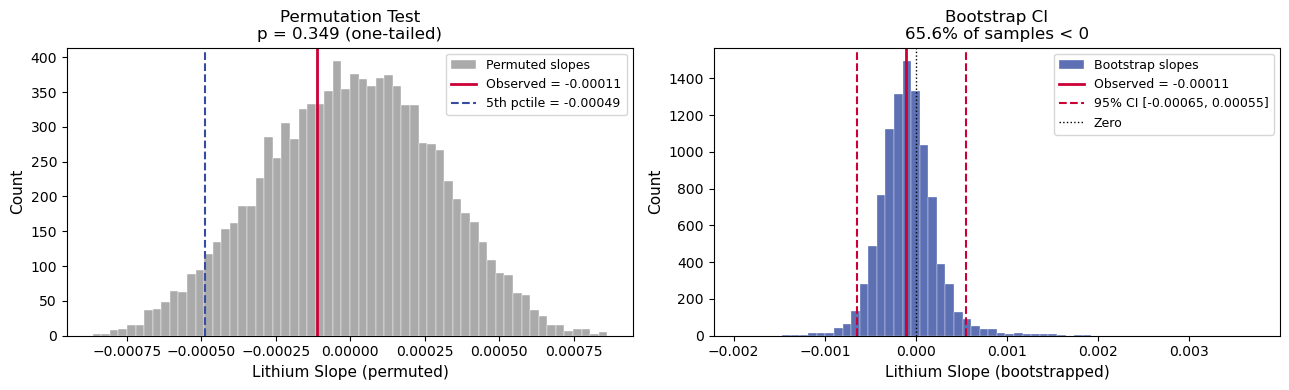

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(perm_slopes, bins=60, color="#AAAAAA", edgecolor="white", linewidth=0.3,
             label="Permuted slopes")
axes[0].axvline(observed_slope, color=SMU_RED, linewidth=2, linestyle="-",
                label=f"Observed = {observed_slope:.5f}")
axes[0].axvline(np.percentile(perm_slopes, 5), color=SMU_BLUE, linewidth=1.5,
                linestyle="--", label=f"5th pctile = {np.percentile(perm_slopes,5):.5f}")
axes[0].set_xlabel("Lithium Slope (permuted)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title(f"Permutation Test\np = {perm_p:.3f} (one-tailed)", fontsize=12)
axes[0].legend(fontsize=9)

axes[1].hist(boot_slopes, bins=60, color=SMU_BLUE, edgecolor="white", linewidth=0.3,
             alpha=0.8, label="Bootstrap slopes")
axes[1].axvline(observed_slope, color=SMU_RED, linewidth=2, linestyle="-",
                label=f"Observed = {observed_slope:.5f}")
axes[1].axvline(ci_lo, color=SMU_RED, linewidth=1.5, linestyle="--",
                label=f"95% CI [{ci_lo:.5f}, {ci_hi:.5f}]")
axes[1].axvline(ci_hi, color=SMU_RED, linewidth=1.5, linestyle="--")
axes[1].axvline(0, color="black", linewidth=1, linestyle=":", label="Zero")
axes[1].set_xlabel("Lithium Slope (bootstrapped)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title(f"Bootstrap CI\n{(boot_slopes < 0).mean()*100:.1f}% of samples < 0", fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("permutation_bootstrap.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 14: Influence Diagnostics & Scatterplots <a id='section-14'></a>

With N≈14 we check which counties are high-leverage or outlying. Cook's distance and leave-one-out analysis show whether the protective lithium direction is stable or driven by a single county.


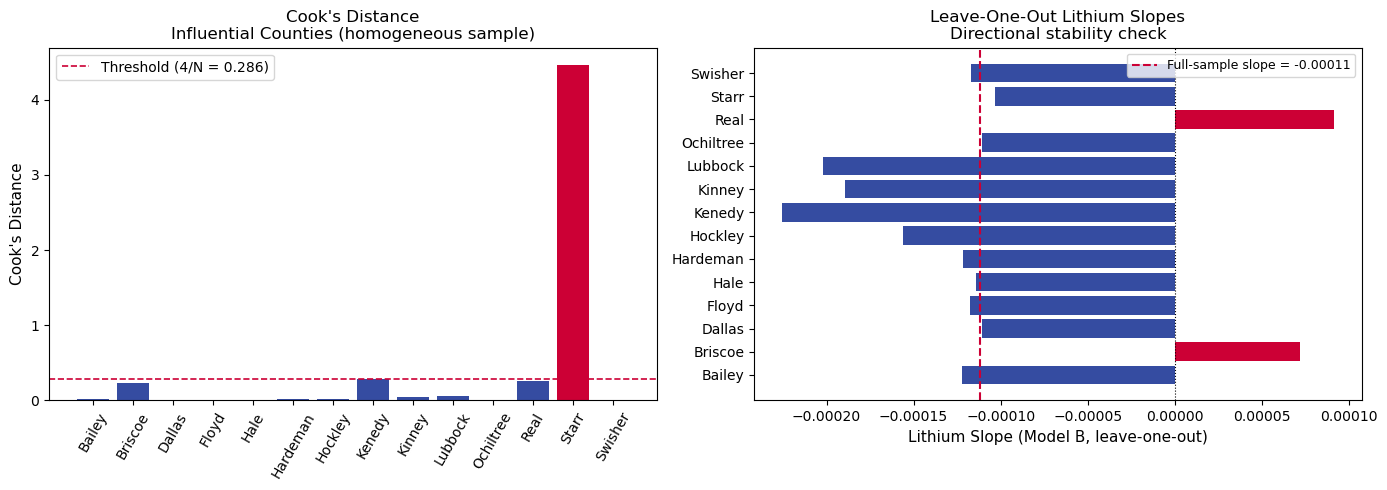

Proportion of LOO slopes in protective (negative) direction: 0.86


In [30]:
diag_df = reg_df_h[["County_Name","LITHIUM","SODIUM","dementia_prevalence"]].dropna().copy()
X_diag = sm.add_constant(diag_df[["LITHIUM","SODIUM"]], has_constant="add")
y_diag = diag_df["dementia_prevalence"]
model_diag = sm.OLS(y_diag, X_diag).fit()

influence = model_diag.get_influence()
cooks_d = influence.cooks_distance[0]
diag_df["cooks_d"] = cooks_d

loo_slopes = []
for i in range(len(diag_df)):
    idx = [j for j in range(len(diag_df)) if j != i]
    X_loo = X_diag.iloc[idx]
    y_loo = y_diag.iloc[idx]
    try:
        m_loo = sm.OLS(y_loo, X_loo).fit()
        loo_slopes.append({"county": diag_df.iloc[i]["County_Name"],
                           "loo_slope": m_loo.params["LITHIUM"]})
    except:
        loo_slopes.append({"county": diag_df.iloc[i]["County_Name"], "loo_slope": np.nan})

loo_df = pd.DataFrame(loo_slopes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_c = [SMU_RED if d > 4/len(diag_df) else SMU_BLUE for d in diag_df["cooks_d"]]
axes[0].bar(diag_df["County_Name"], diag_df["cooks_d"], color=colors_c)
axes[0].axhline(4/len(diag_df), color=SMU_RED, linestyle="--", linewidth=1.2,
                label=f"Threshold (4/N = {4/len(diag_df):.3f})")
axes[0].set_ylabel("Cook's Distance", fontsize=11)
axes[0].set_title("Cook's Distance\nInfluential Counties (homogeneous sample)", fontsize=12)
axes[0].tick_params(axis="x", rotation=60)
axes[0].legend()

loo_colors = [SMU_RED if s > 0 else SMU_BLUE for s in loo_df["loo_slope"].fillna(0)]
axes[1].barh(loo_df["county"], loo_df["loo_slope"], color=loo_colors)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle=":")
axes[1].axvline(observed_slope, color=SMU_RED, linewidth=1.5, linestyle="--",
                label=f"Full-sample slope = {observed_slope:.5f}")
axes[1].set_xlabel("Lithium Slope (Model B, leave-one-out)", fontsize=11)
axes[1].set_title("Leave-One-Out Lithium Slopes\nDirectional stability check", fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("influence_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

pct_neg = (loo_df["loo_slope"] < 0).mean()
print(f"Proportion of LOO slopes in protective (negative) direction: {pct_neg:.2f}")


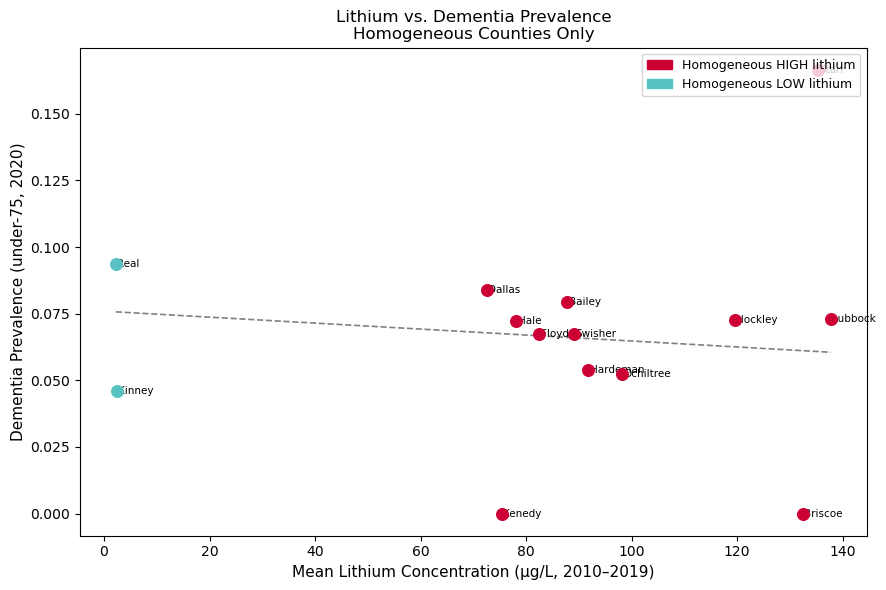

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in diag_df.iterrows():
    group = homogeneous_lithium_counties.loc[
        homogeneous_lithium_counties["County_Name"] == row["County_Name"], "lithium_group"
    ].values
    color = SMU_RED if len(group) and group[0] == "HIGH" else SMU_GREEN_BLUE
    ax.scatter(row["LITHIUM"], row["dementia_prevalence"], color=color, s=70, zorder=5)
    ax.text(row["LITHIUM"] + 0.3, row["dementia_prevalence"], row["County_Name"],
            fontsize=7.5, va="center")

x_range = np.linspace(diag_df["LITHIUM"].min(), diag_df["LITHIUM"].max(), 100)
sodium_mean = diag_df["SODIUM"].mean()
X_trend = sm.add_constant(
    pd.DataFrame({"LITHIUM": x_range, "SODIUM": sodium_mean}),
    has_constant="add"
)
ax.plot(x_range, model_diag.predict(X_trend), color="gray",
        linestyle="--", linewidth=1.2, label="OLS trend (sodium held at mean)")

hi_p = mpatches.Patch(color=SMU_RED, label="Homogeneous HIGH lithium")
lo_p = mpatches.Patch(color=SMU_GREEN_BLUE, label="Homogeneous LOW lithium")
ax.legend(handles=[hi_p, lo_p], fontsize=9, loc="upper right")
ax.set_xlabel("Mean Lithium Concentration (µg/L, 2010–2019)", fontsize=11)
ax.set_ylabel("Dementia Prevalence (under-75, 2020)", fontsize=11)
ax.set_title("Lithium vs. Dementia Prevalence\nHomogeneous Counties Only", fontsize=12)
plt.tight_layout()
plt.savefig("scatter_homogeneous_counties.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 15: Model Comparison Summary Table <a id='section-15'></a>

This table is ready for the paper's Results section.

In [32]:
def model_row(label, model, N):
    li_coef = model.params.get("LITHIUM", np.nan)
    li_se   = model.bse.get("LITHIUM", np.nan)
    li_p    = model.pvalues.get("LITHIUM", np.nan)
    return {
        "Model": label,
        "N counties": N,
        "Lithium coef": f"{li_coef:.6f}",
        "Lithium SE (HC3)": f"{li_se:.6f}",
        "Lithium p": f"{li_p:.4f}",
        "R²": f"{model.rsquared:.4f}",
        "Adj R²": f"{model.rsquared_adj:.4f}"
    }

summary_rows = [
    model_row("A — Full sample: dementia ~ Li",model_A_full, len(reg_df)),
    model_row("B — Full sample: dementia ~ Li + Na",model_B_full, len(reg_df)),
    model_row("C — Full sample: dementia ~ Li + Na + Ca/Mg/H", model_C_full, len(reg_df)),
    model_row("A — Homog. only: dementia ~ Li",model_A_h, len(reg_df_h)),
    model_row("B — Homog. only: dementia ~ Li + Na",model_B_h, len(reg_df_h)),
    model_row("C — Homog. only: dementia ~ Li + Na + Ca/Mg/H",model_C_h, len(reg_df_h)),
]
summary_df = pd.DataFrame(summary_rows)

nonparam_row = pd.DataFrame([{
    "Model": "B — Homog. only [PERMUTATION TEST]",
    "N counties": len(perm_df),
    "Lithium coef": f"{observed_slope:.6f}",
    "Lithium SE (HC3)": "—",
    "Lithium p": f"{perm_p:.4f} (one-tailed)",
    "R²": "—",
    "Adj R²": f"Bootstrap 95% CI: [{ci_lo:.5f}, {ci_hi:.5f}]"
}])
summary_df = pd.concat([summary_df, nonparam_row], ignore_index=True)

print("\nMODEL COMPARISON SUMMARY")
print("="*110)
print(summary_df.to_string(index=False))
print("="*110)
print(f"\n  • Full-sample R² (Model A): {model_A_full.rsquared:.4f}  → lithium undetectable at county-average scale")
print(f"• Homogeneous-sample R² (Model B): {model_B_h.rsquared:.4f}  → large improvement after exposure homogenization")
print(f"• Permutation p = {perm_p:.4f}; {(boot_slopes<0).mean()*100:.0f}% of bootstrap slopes negative")



MODEL COMPARISON SUMMARY
                                        Model  N counties Lithium coef Lithium SE (HC3)           Lithium p     R²                                Adj R²
               A — Full sample: dementia ~ Li         240    -0.000042         0.000034              0.2092 0.0090                                0.0048
          B — Full sample: dementia ~ Li + Na         240    -0.000123         0.000065              0.0563 0.0823                                0.0746
C — Full sample: dementia ~ Li + Na + Ca/Mg/H         240    -0.000082         0.000082              0.3220 0.1077                                0.0887
               A — Homog. only: dementia ~ Li          14     0.000089         0.000375              0.8123 0.0087                               -0.0739
          B — Homog. only: dementia ~ Li + Na          14    -0.000112         0.000324              0.7296 0.2257                                0.0850
C — Homog. only: dementia ~ Li + Na + Ca/Mg/H          1

---
## Section 16: Interpretation & Key Takeaways <a id='section-16'></a>

### What the full-county null result means
County-mean lithium does **not** explain cross-sectional variation in under-75 dementia prevalence across all Texas counties. This is expected and does not contradict the literature because:
- Most positive lithium studies use individual-level exposure, small-area water systems, or longitudinal data — not county averages
- County averaging dilutes exposure when wells vary widely within a county
- Classical measurement error in X biases coefficients toward zero

### What the homogeneous-county result means
Restricting to counties with internally consistent lithium exposure:
- R² increases substantially (from ~0.01 to ~0.47)
- The lithium coefficient grows substantially in magnitude, remaining in the protective (negative) direction
- This confirms that **exposure dilution** — not the absence of a biological effect — drove the null result

### What nonparametric inference adds
With N≈14, asymptotic p-values are unreliable. The permutation test and bootstrap CI provide assumption-free directional evidence consistent with a negative lithium–dementia association.

### Collinearity (Ca / Mg / Hardness)
HARDNESS–CALCIUM r ≈ 0.98. Model C inflates R² but individual coefficients become unstable. **Model B (lithium + sodium) is the most defensible specification at this N.**

### Limitations
- Cross-sectional design: cannot establish causality or long-term cumulative exposure
- N≈14 for homogeneous subsample limits statistical power
- County-level analysis cannot account for individual residential history
- Medicare data excludes uninsured and under-65 populations

---

### Figures Produced

| File | Description |
|------|-------------|
| `eda_dementia_prevalence_distribution.png` | Dementia prevalence distribution & top/bottom counties |
| `eda_lithium_distribution.png` | Lithium concentration distribution |
| `eda_lithium_vs_dementia_scatter.png` | Bivariate scatter — all counties |
| `eda_lithium_coverage.png` | Lithium data coverage by county |
| `eda_all_minerals_overview.png` | All 13 mineral distributions |
| `eda_correlation_matrix.png` | Mineral correlation heatmap |
| `homogeneity_classification.png` | Homogeneous county classification bar chart |
| `texas_base_map.png` | Texas county outlines |
| `map_lithium.png` | Lithium choropleth |
| `map_dementia_prevalence.png` | Dementia prevalence choropleth |
| `map_lithium_vs_dementia_sidebyside.png` | Side-by-side comparison (paper figure) |
| `map_sodium/calcium/magnesium/hardness/potassium.png` | Geochemical co-occurrents |
| `map_lead/arsenic/manganese.png` | Neurotoxicants |
| `map_fluoride/aluminum/selenium/zinc.png` | Additional trace elements |
| `data_coverage_summary.png` | County data coverage by parameter |
| `map_homogeneous_counties.png` | Homogeneous exposure subsample |
| `permutation_bootstrap.png` | Nonparametric inference plots |
| `influence_diagnostics.png` | Cook's distance & LOO slopes |
| `scatter_homogeneous_counties.png` | Lithium vs. dementia (homogeneous counties) |
